[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab0-ML/notebooks/02-Binary_classification.ipynb)

Version 20.12.2025, A. Lundervold / A. S. Lundervold

# Binary Classification

Welcome to this notebook on **binary classification** — one of the most fundamental and important tasks in machine learning!

In this notebook, you will:
- Understand the difference between **classification** and **regression**
- Train a classification model on a medical dataset
- Learn key evaluation metrics: precision, recall, specificity, and the F₁-score
- Explore **cross-validation** for robust model assessment
- Understand the **precision/recall trade-off** and how it impacts model selection

**Why is this important in medicine?**

Binary classification is used daily in clinical practice:
- Does the patient have diabetes or not?
- Is a tumor malignant or benign?
- Is an ECG normal or pathological?

Understanding how we evaluate such models — especially the balance between different types of errors — is critical for using machine learning responsibly in clinical practice.

---

> 💡 **Tip:** You will find cells labeled "Your Turn!" below. They are meant for you to experiment with the code yourself.

> 🔧 **Advice:** Feel free to modify the code, change parameters, and explore on your own. Hands-on experimentation leads to deeper understanding.

## Classification versus regression

Before we begin, let’s clarify two central concepts in supervised machine learning.

### Classification

Classification is about assigning a **category** or **class** to a data point. We want to decide which of N possible classes a data point belongs to.

Mathematically, we can write this as a *function mapping inputs to a discrete set of classes*:

$$f: X \longrightarrow \{1, \dots, N\}$$

#### Binary classification (N = 2)

When there are only two possible classes, we call it **binary classification**:

> 📚 **General example:** A spam filter classifies emails as either "spam" or "not spam". Each email ends up in one and only one of these categories.

> 🏥 **Medical examples of binary classification:**
> - **Diabetes screening:** Does the patient have diabetes (yes/no)?
> - **Mammography:** Is the visible lesion malignant or benign?
> - **COVID-19 test:** Is the patient infected or not?
> - **ECG interpretation:** Is the heart rhythm normal or pathological (e.g., atrial fibrillation)?
> - **Chest X-ray:** Does the image show signs of pneumonia or not?
> - **Skin lesion analysis:** Is the mole melanoma or benign?
> - **Sepsis prediction:** Will the patient develop sepsis within 6 hours?

#### Multi-class classification (N > 2)

When there are more than two classes, we call it **multi-class classification**:

> 🏥 **Medical examples of multi-class classification:**
> - **Blood type determination:** A, B, AB, or O
> - **Cancer staging:** Stage I, II, III, or IV
> - **Brain tumor classification:** Glioblastoma, meningioma, pituitary adenoma, or other
> - **Skin conditions:** Eczema, psoriasis, acne, rosacea, or other
> - **Arrhythmia classification:** Sinus rhythm, atrial fibrillation, atrial flutter, ventricular tachycardia, etc.
> - **Retinal disease:** Normal, diabetic retinopathy, macular degeneration, glaucoma
> - **Psychiatric diagnosis:** Depression, anxiety disorder, bipolar disorder, schizophrenia, etc.

---

### Regression

Regression is about predicting a **continuous value**. Imagine predicting the price of a house based on size, location, and number of rooms. The outcome is a number that can vary continuously.

Mathematically, *regression is a mapping from inputs to the real numbers*:

$$f: X \longrightarrow \mathbb{R}$$

> 📚 **General example:** Predicting house prices based on size and location.

> 🏥 **Medical examples of regression:**
> - **Blood glucose level:** Predicting HbA1c based on diet and activity level
> - **Blood pressure:** Estimating systolic blood pressure based on lifestyle factors
> - **Survival time:** Predicting expected lifespan for cancer patients
> - **Medication dosing:** Calculating an optimal dose based on patient characteristics
> - **Kidney function:** Estimating GFR (glomerular filtration rate) from creatinine and age
> - **Birth weight:** Predicting a baby's weight at birth

---

### How do you tell them apart?

A key question when you encounter a new problem is:

> 🤔 "Are the possible predictions **continuous** or **discrete**?"

- **Continuous values** → Regression (e.g., blood pressure, GFR, medication dose)
- **Discrete categories** → Classification (e.g., sick/healthy, blood type, cancer stage)

---

### Regression → classification: reformulating the problem

> ⚠️ **Important insight:** Many medical problems can be formulated as *either* regression *or* classification! This choice has major consequences for modeling, interpretation, and clinical use.

#### Medical examples of reformulation

| Medical problem | As regression | As classification |
|-----------------|--------------|------------------|
| **Blood pressure** | Predict systolic pressure (e.g., 142 mmHg) | Normal / Elevated / Hypertension grade 1/2/3 |
| **Kidney function** | Estimate GFR (e.g., 58 ml/min/1.73m²) | Normal / Mild / Moderate / Severe kidney failure |
| **Blood glucose** | Predict HbA1c (e.g., 6.8%) | Normal / Prediabetes / Diabetes |
| **Body weight** | Predict BMI (e.g., 27.3) | Underweight / Normal / Overweight / Obesity |
| **Fetal growth** | Estimate birth weight (e.g., 3200 g) | SGA / Normal / LGA (small/large for gestational age) |
| **Liver function** | Predict Child-Pugh score (5–15) | Class A / B / C |
| **Cardiac function** | Estimate ejection fraction (e.g., 45%) | Normal / Mild / Moderate / Severely reduced |
| **Pain level** | Predict VAS score (0–10) | None / Mild / Moderate / Severe pain |
| **Cancer risk** | Estimate 5-year risk (e.g., 12%) | Low / Medium / High risk |
| **Survival** | Predict months to event | Short / Medium / Long expected survival |

#### ✅ Arguments FOR reformulating regression as classification

1. **Clinical relevance:** Clinicians often make binary or categorical decisions ("treat" vs "do not treat"), not precise numerical decisions
2. **Robustness to noise:** Classification is less sensitive to small measurement uncertainties — 141 vs 142 mmHg yields the same category
3. **Easier communication:** "You have elevated blood pressure" is easier to communicate than "Your predicted systolic pressure is 143.7 mmHg"
4. **Established thresholds:** Medicine often has well-defined cutoffs based on clinical studies (e.g., HbA1c ≥ 6.5% = diabetes)
5. **Treatment guidelines:** Clinical guidelines are often based on categories, not continuous values
6. **Easier evaluation:** Classification metrics (precision, recall, F₁) can be more intuitive than regression metrics (MSE, MAE)

#### ❌ Arguments AGAINST reformulating regression as classification

1. **Loss of information:** By categorizing, we lose nuance — a patient with GFR 59 and one with GFR 31 may both fall into "moderate kidney failure", but have very different prognoses
2. **Threshold issues:** Patients near cutoffs can "flip" between categories due to small measurement errors — HbA1c 6.4% vs 6.5% yields a completely different diagnosis
3. **Artificial boundaries:** Categories are often based on consensus, not biological "natural" separations — the body does not "know" that 140 mmHg is "the boundary"
4. **Less informative predictions:** A regression model predicting HbA1c = 6.8% provides more information than only "diabetes"
5. **Harder to optimize near boundaries:** Classification can be difficult near thresholds — the model must "choose a side" even when uncertainty is high
6. **Potential undertreatment:** Patients just below a threshold might not receive follow-up they could benefit from

#### 💡 Practical recommendation

> 🤔 **Rule of thumb:** Start with what matches the clinical question.
> - If the decision is binary (treat / do not treat) → consider classification
> - If nuanced values matter for follow-up → consider regression
> - Often you can do both: train a regression model and apply thresholds afterwards

**Hybrid approach:** Train a regression model that predicts the continuous value, then use clinically established thresholds to categorize. This gives you the best of both worlds — you retain the information, while still enabling categorical decisions.

### 🔬 Deep dive: mathematical methods for thresholding

When we reformulate a regression problem as a classification problem, we must decide **where the boundaries should be**. This choice is non-trivial and can be made in several ways. Let’s explore the most important approaches.

---

<details>
<summary>📊 <b>1. A priori thresholding (expert-based)</b> — click to expand</summary>

### Intuition first

Imagine you are a clinician deciding whether a patient has diabetes. Instead of deriving the cutoffs yourself, you consult clinical guidelines. They state: "HbA1c ≥ 6.5% = diabetes". This threshold is defined by experts based on large studies showing that the risk of diabetes complications increases substantially above that level.

> 🎯 **Key idea:** Use thresholds already established by the clinical/scientific community, grounded in clinical experience and research evidence.

**Why does this work?**

Clinical thresholds are rarely arbitrary. They are typically chosen because:
1. **Biological significance:** Something changes in the body around this value
2. **Clinical utility:** Treatment yields benefit above/below this cutoff
3. **Epidemiological evidence:** Large population studies show increased risk

> 🏥 **Concrete examples:**
> - **Blood pressure:** Hypertension is defined as ≥140/90 mmHg (based on cardiovascular risk)
> - **Cholesterol:** LDL ≥ 3.0 mmol/L is considered elevated
> - **Kidney function:** GFR < 60 indicates chronic kidney disease
> - **Blood glucose:** Fasting glucose ≥ 7.0 mmol/L = diabetes

### The mathematical formulation

Given a continuous prediction $\hat{y} \in \mathbb{R}$ and a fixed threshold $\tau$:

$$\hat{c} = \begin{cases} 1 & \text{if } \hat{y} \geq \tau \\ 0 & \text{otherwise} \end{cases}$$

For multi-class classification with thresholds $\tau_1 < \tau_2 < \dots < \tau_{k-1}$:

$$\hat{c} = j \quad \text{if } \tau_{j-1} \leq \hat{y} < \tau_j$$

### Practical implementation in Python

```python
import numpy as np

# ============================================================================
# A PRIORI THRESHOLDING — Use expert thresholds directly
# ============================================================================

def classify_hba1c(hba1c_values):
    """
    Classify patients based on HbA1c using WHO/ADA thresholds.

    Parameters:
        hba1c_values: Array of HbA1c measurements (in %)

    Returns:
        Array of classifications: 0=normal, 1=prediabetes, 2=diabetes
    """
    hba1c = np.array(hba1c_values)

    # Define thresholds based on clinical guidelines
    THRESHOLD_PREDIABETES = 5.7  # WHO/ADA cutoff
    THRESHOLD_DIABETES = 6.5     # WHO/ADA cutoff

    # Use np.select for multi-category classification
    conditions = [
        hba1c < THRESHOLD_PREDIABETES,
        (hba1c >= THRESHOLD_PREDIABETES) & (hba1c < THRESHOLD_DIABETES),
        hba1c >= THRESHOLD_DIABETES,
    ]
    categories = [0, 1, 2]  # normal, prediabetes, diabetes

    return np.select(conditions, categories)

# Example usage
hba1c_measurements = [5.2, 5.8, 6.1, 6.7, 7.2, 5.5]
classes = classify_hba1c(hba1c_measurements)
print(f"HbA1c: {hba1c_measurements}")
print(f"Classes: {classes}")  # [0, 1, 1, 2, 2, 0]

# Binary version (diabetes yes/no)
def has_diabetes(hba1c_values, threshold=6.5):
    """Simple binary classification: diabetes if HbA1c >= threshold."""
    return (np.array(hba1c_values) >= threshold).astype(int)
```

### Pros and cons

| ✅ Pros | ❌ Cons |
|------|------|
| Easy to implement and explain | Does not account for model uncertainty |
| Based on established medical evidence | May be suboptimal for your specific population |
| Consistent across studies/institutions | Cutoffs may become outdated |
| Easy for patients and clinicians to understand | "One size fits all" — ignores individual variation |

</details>

---

<details>
<summary>📈 <b>2. Data-driven thresholding</b> — click to expand</summary>

### Intuition first

Instead of using a predefined cutoff, we ask: "Which threshold gives the best performance on *our* data?" We try many different thresholds and choose the one that optimizes a criterion we care about.

> 🎯 **Key idea:** Let the data tell us where the boundary should be, based on what we want to achieve.

**Analogy:** Imagine adjusting the volume on a radio. You try different levels until you find what sounds best — not too low (you miss information), not too high (noise). In the same way, we try different thresholds until we find the one that best balances errors.

### Three main approaches

#### 2a. Youden’s J statistic

**Intuition:** Find the threshold where we are *as good as possible* at both catching sick patients (sensitivity) and avoiding false alarms (specificity).

Mathematically, we choose the threshold that maximizes:

$$J = \max_\tau \left[ \text{Sensitivity}(\tau) + \text{Specificity}(\tau) - 1 \right]$$

> 💡 **Geometric interpretation:** This is the point on the ROC curve that is farthest from the "random guessing" diagonal.

#### 2b. Cost-based thresholding

**Intuition:** Not all errors are equally serious. Missing a cancer diagnosis (FN) is worse than doing an unnecessary biopsy (FP). We weight errors by their severity.

$$\tau^* = \arg\min_\tau \left[ C_{FP} \cdot FP(\tau) + C_{FN} \cdot FN(\tau) \right]$$

> 🏥 **Real-world example:**
> - **Cancer screening:** $C_{FN} = 1000$ (missing cancer is catastrophic), $C_{FP} = 10$ (an unnecessary biopsy is unpleasant but acceptable) → choose a low threshold
> - **Antibiotic prescribing:** $C_{FN} = 50$ (untreated infection), $C_{FP} = 100$ (antibiotic resistance) → choose a higher threshold

#### 2c. F-score optimization

**Intuition:** Balance precision and recall by optimizing the $F_\beta$ score:

$$F_\beta = (1 + \beta^2) \cdot \frac{\text{precision} \cdot \text{recall}}{\beta^2 \cdot \text{precision} + \text{recall}}$$

- $\beta = 1$: Equal weight on precision and recall (standard $F_1$)
- $\beta = 2$: "We must catch all sick patients!" — recall matters most
- $\beta = 0.5$: "Avoid false alarms!" — precision matters most

### Practical implementation in Python

```python
import numpy as np
from sklearn.metrics import roc_curve, precision_recall_curve

# ============================================================================
# DATA-DRIVEN THRESHOLDING — Find an optimal threshold from data
# ============================================================================

def find_youden_threshold(y_true, y_scores):
    """
    Find the optimal threshold by maximizing Youden's J statistic.

    Parameters:
        y_true: True classes (0/1)
        y_scores: Predicted probabilities or scores

    Returns:
        optimal_threshold: Threshold that maximizes J = sensitivity + specificity - 1
        j_max: Maximum J value
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)

    # Youden's J = TPR - FPR = sensitivity + specificity - 1
    J = tpr - fpr
    optimal_idx = np.argmax(J)

    return thresholds[optimal_idx], J[optimal_idx]


def find_f1_threshold(y_true, y_scores):
    """Find the optimal threshold by maximizing the F1 score."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_scores)

    # Compute F1 for each threshold (avoid division by zero)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

    # precision_recall_curve returns n+1 values, so we drop the last
    optimal_idx = np.argmax(f1_scores[:-1])

    return thresholds[optimal_idx], f1_scores[optimal_idx]


def find_cost_based_threshold(y_true, y_scores, cost_fp=1, cost_fn=10):
    """
    Find the threshold that minimizes total cost.

    Parameters:
        cost_fp: Cost per false positive
        cost_fn: Cost per false negative (often higher in medicine)
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)

    # Count positives/negatives
    n_pos = np.sum(y_true == 1)
    n_neg = np.sum(y_true == 0)

    # FP = FPR * N, FN = (1-TPR) * P
    fp_counts = fpr * n_neg
    fn_counts = (1 - tpr) * n_pos

    total_cost = cost_fp * fp_counts + cost_fn * fn_counts
    optimal_idx = np.argmin(total_cost)

    return thresholds[optimal_idx], total_cost[optimal_idx]

# Example usage
# y_true = np.array([0, 0, 1, 1, 1, 0, 1, 0])
# y_scores = np.array([0.1, 0.3, 0.6, 0.8, 0.7, 0.4, 0.9, 0.2])
#
# threshold_youden, j_value = find_youden_threshold(y_true, y_scores)
# threshold_f1, f1_value = find_f1_threshold(y_true, y_scores)
# threshold_cost, min_cost = find_cost_based_threshold(y_true, y_scores, cost_fp=1, cost_fn=10)
```

### Pros and cons

| ✅ Pros | ❌ Cons |
|------|------|
| Optimized for your specific population | Can overfit to training data |
| Flexible — choose criterion as needed | Requires validation data |
| Accounts for class imbalance | Threshold can vary between datasets |
| Can incorporate cost considerations | Requires you to define the costs |

</details>

---

<details>
<summary>📉 <b>3. Quantile-based thresholding</b> — click to expand</summary>

### Intuition first

Instead of asking "at which value does risk change?", we ask: "How can we split patients into groups of equal size?"

> 🎯 **Key idea:** Split the population into quantiles (e.g., tertiles, quartiles, deciles) based on the predicted value.

**Analogy:** Imagine a teacher grading, but instead of absolute cutoffs, they decide that "the top 10% get an A, the next 20% get a B", etc. That is quantile-based thresholding.

**When is this used in medicine?**

- **Risk tertiles:** Split patients into "low", "medium", and "high" risk
- **Treatment prioritization:** "Follow up the 10% with the highest risk intensively"
- **Resource allocation:** "Allocate specialist resources to the top quartile"

### The mathematical formulation

Split the population based on percentiles of the predicted value:

$$\tau_j = Q_j(\hat{y}), \quad j = 1, \dots, k-1$$

where $Q_j$ is the $j$-th quantile (e.g., $Q_{0.33}$ is the 33rd percentile).

> 🏥 **Example:** Cardiovascular risk score
> - **Low risk:** Lowest tertile (below the 33rd percentile)
> - **Medium risk:** Middle tertile (33rd to 67th percentile)
> - **High risk:** Highest tertile (above the 67th percentile)

### Practical implementation in Python

```python
import numpy as np
import pandas as pd

# ============================================================================
# QUANTILE-BASED THRESHOLDING — Split into groups by percentiles
# ============================================================================

def classify_quantiles(y_scores, n_groups=3, labels=None):
    """
    Split predictions into quantile-based groups.

    Parameters:
        y_scores: Predicted scores/probabilities
        n_groups: Number of groups (3=tertiles, 4=quartiles, 10=deciles)
        labels: Optional names for the groups

    Returns:
        classifications: Group membership (0 to n_groups-1)
        thresholds: Quantile cutoffs used
    """
    # Compute percentile thresholds
    percentiles = np.linspace(0, 100, n_groups + 1)[1:-1]
    thresholds = np.percentile(y_scores, percentiles)

    # Classify based on thresholds
    classifications = np.digitize(y_scores, thresholds)

    if labels:
        # Convert to categorical labels
        return np.array(labels)[classifications], thresholds

    return classifications, thresholds


def split_into_risk_groups(risk_scores, groups=['Low', 'Medium', 'High']):
    """
    Split patients into named risk groups.

    Example:
        risk = [0.1, 0.3, 0.5, 0.7, 0.9, 0.2, 0.6, 0.8, 0.4]
        groups, cutoffs = split_into_risk_groups(risk)
    """
    n_groups = len(groups)
    return classify_quantiles(risk_scores, n_groups=n_groups, labels=groups)

# More advanced: use pd.qcut for a simple implementation
def quantile_classification_pandas(df, column, n_groups=4):
    """Add a quantile-based classification to a DataFrame."""
    df['risk_group'] = pd.qcut(
        df[column],
        q=n_groups,
        labels=[f'Q{i+1}' for i in range(n_groups)],
    )
    return df

# Example usage
# risk_scores = np.random.random(100)  # Simulated risk scores
# groups, cutoffs = split_into_risk_groups(risk_scores)
# print(f"Threshold cutoffs: {cutoffs}")
# print(f"Distribution: {np.unique(groups, return_counts=True)}")
```

### Pros and cons

| ✅ Pros | ❌ Cons |
|------|------|
| Always produces balanced groups | Cutoffs have no biological meaning |
| Practical for capacity planning | Changes with the population |
| Easy to communicate ("top 10%") | A patient in "high risk" in one population may be "low risk" in another |
| Robust to outliers | Ignores absolute risk level |

> ⚠️ **Important warning:** A patient with "low risk" relative to others can still have high absolute risk. Quantiles describe relative position, not absolute danger.

</details>

---

<details>
<summary>🎲 <b>4. Probabilistic thresholding (Bayesian)</b> — click to expand</summary>

### Intuition first

Instead of saying "above threshold = sick", we say "this patient has a 73% probability of being sick". Then we decide how high the probability must be before we take action.

> 🎯 **Key idea:** The model outputs probabilities, not only yes/no answers. We choose a probability threshold for action.

**Analogy:** Imagine deciding whether to bring an umbrella. If the forecast says "30% chance of rain", you might skip it. But at "80% chance of rain", you probably bring it. Where is your personal threshold? It depends on how bad it is to get wet versus carrying an unnecessary umbrella.

### Why probabilities are useful

1. **Richer information:** "85% chance of diabetes" vs "51% chance of diabetes" are both "positive", but may warrant different follow-up
2. **Patient communication:** "You have a 3 out of 4 chance of having this condition" is informative
3. **Decision support:** Clinicians can incorporate other factors into their assessment

### The mathematical formulation

Given a posterior probability $P(c=1 | \hat{y})$:

$$\hat{c} = \begin{cases} 1 & \text{if } P(c=1 | \hat{y}) \geq \pi \\ 0 & \text{otherwise} \end{cases}$$

where $\pi$ is the probability threshold (often 0.5, but it can be adjusted).

**When should you adjust $\pi$?**
- **Low prevalence:** If the disease is rare, $\pi = 0.5$ may yield too many false positives
- **Asymmetric costs:** If FN is worse than FP, lower $\pi$
- **Screening vs. diagnosis:** Screening often uses a lower $\pi$

### Calibration is critical

> ⚠️ **Important:** For this to work, predicted probabilities must be *calibrated* — i.e., when the model says "80% chance", then about 80% of such cases should truly be positive.

**How to check calibration:**
- Plot predicted probabilities vs observed frequencies
- Use the Brier score or a calibration plot
- Consider recalibration (Platt scaling, isotonic regression)

### Practical implementation in Python

```python
import numpy as np
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

# ============================================================================
# PROBABILISTIC THRESHOLDING — Work with probabilities
# ============================================================================

def classify_with_probability_threshold(y_proba, threshold=0.5):
    """
    Classify using a probability threshold.

    Parameters:
        y_proba: Predicted probabilities for the positive class
        threshold: Probability threshold (default 0.5)

    Returns:
        classifications: 0 or 1
    """
    return (np.array(y_proba) >= threshold).astype(int)


def check_calibration(y_true, y_proba, n_bins=10, show_plot=True):
    """
    Check how well predicted probabilities are calibrated.

    Returns:
        brier_score: Lower is better (0 = perfect)
        fraction_of_positives: Observed fraction positive per bin
        mean_predicted_value: Mean predicted probability per bin
    """
    brier = brier_score_loss(y_true, y_proba)
    fraction_pos, mean_pred = calibration_curve(y_true, y_proba, n_bins=n_bins)

    if show_plot:
        plt.figure(figsize=(8, 6))
        plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
        plt.plot(mean_pred, fraction_pos, 'o-', label=f'Model (Brier={brier:.3f})')
        plt.xlabel('Mean predicted probability')
        plt.ylabel('Observed fraction positive')
        plt.title('Calibration plot')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return brier, fraction_pos, mean_pred


def recalibrate_model(model, X_val, y_val, method='sigmoid'):
    """
    Recalibrate a model using Platt scaling or isotonic regression.

    Parameters:
        model: A trained scikit-learn model
        X_val: Validation data (features)
        y_val: Validation data (labels)
        method: 'sigmoid' (Platt scaling) or 'isotonic'
    """
    calibrated_model = CalibratedClassifierCV(model, method=method, cv='prefit')
    calibrated_model.fit(X_val, y_val)
    return calibrated_model

# Adjusting threshold based on prevalence
def adjust_threshold_for_prevalence(original_threshold, training_prevalence, population_prevalence):
    """
    Adjust a threshold when population prevalence differs from training prevalence.

    Based on: threshold_new = threshold * (p_pop/p_train) /
                           (threshold * (p_pop/p_train) + (1-threshold))
    """
    ratio = population_prevalence / training_prevalence
    return (original_threshold * ratio) / (original_threshold * ratio + (1 - original_threshold))
```

### Pros and cons

| ✅ Pros | ❌ Cons |
|------|------|
| Provides richer information | Requires a well-calibrated model |
| Enables individualized decision-making | Many ML models are poorly calibrated |
| Can be combined with patient preferences | Harder to communicate than yes/no |
| Flexible — different $\pi$ for different purposes | Requires probability literacy |

</details>

---

<details>
<summary>⚖️ <b>5. Optimal decision theory</b> — click to expand</summary>

### Intuition first

This approach asks: "What is the *value* of each possible outcome?" We explicitly define how good or bad it is to have true/false positives/negatives, and choose the threshold that maximizes expected value.

> 🎯 **Key idea:** Quantify the utility (or cost) of all outcomes, and optimize for total expected utility.

**Analogy:** Imagine you run a hospital and must set policy for CT screening. You need to weigh:
- **Benefit of detecting cancer early:** Lives saved, cheaper treatment
- **Cost of a false alarm:** Unnecessary radiation, anxiety, further work-up
- **Cost of missing cancer:** Lost life, more expensive treatment later
- **Benefit of correctly ruling out cancer:** Reassured patient

Optimal decision theory balances all of these considerations mathematically.

### The mathematical formulation

We define a **utility function** $U$ that assigns a value to each outcome:

| | Predicted positive | Predicted negative |
|---|---|---|
| **Actual positive** | $U_{TP}$ | $U_{FN}$ |
| **Actual negative** | $U_{FP}$ | $U_{TN}$ |

Find the threshold that maximizes expected utility:

$$\tau^* = \arg\max_\tau \mathbb{E}[U(\hat{c}, c)]$$

Expanded:

$$\tau^* = \arg\max_\tau \left[ U_{TP} \cdot TP(\tau) + U_{TN} \cdot TN(\tau) + U_{FP} \cdot FP(\tau) + U_{FN} \cdot FN(\tau) \right]$$

### Example: sepsis prediction

> 🏥 **Scenario:** A model predicts whether a patient will develop sepsis within 6 hours.

| Outcome | Description | Utility |
|--------|-------------|---------|
| **TP** | Detect sepsis early → start treatment → save lives | +100 |
| **TN** | Correctly identify a healthy patient → avoid unnecessary treatment | +1 |
| **FP** | False alarm → unnecessary antibiotics/monitoring | -10 |
| **FN** | Miss sepsis → delayed treatment → potentially fatal | -1000 |

With these values, the optimal threshold will be *low* (catch many cases, accept some false alarms), because $|U_{FN}| >> |U_{FP}|$.

### How can we estimate utility values?

1. **Clinical consensus:** An expert panel discusses and agrees on relative values
2. **Health economic analyses:** QALY (quality-adjusted life years), cost-effectiveness
3. **Patient preferences:** Ask patients about trade-offs
4. **Sensitivity analysis:** Test how robust the decision is across plausible values

### Practical implementation in Python

```python
import numpy as np
from sklearn.metrics import roc_curve

# ============================================================================
# OPTIMAL DECISION THEORY — Maximize expected utility
# ============================================================================

def find_utility_optimal_threshold(
    y_true,
    y_scores,
    utility_tp=100,
    utility_tn=1,
    utility_fp=-10,
    utility_fn=-1000,
):
    """
    Find the threshold that maximizes expected utility.

    Parameters:
        y_true: True classes (0/1)
        y_scores: Predicted probabilities
        utility_tp: Utility of a true positive (e.g., early treatment)
        utility_tn: Utility of a true negative (e.g., avoid overtreatment)
        utility_fp: Utility of a false positive (negative = cost)
        utility_fn: Utility of a false negative (negative = cost, often large)

    Returns:
        optimal_threshold: Threshold that maximizes expected utility
        max_utility: The maximum expected utility
        all_utilities: Utility for each threshold (for plotting)
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)

    # Count positives/negatives
    n_pos = np.sum(y_true == 1)
    n_neg = np.sum(y_true == 0)

    # For each threshold, compute expected TP, TN, FP, FN
    tp_counts = tpr * n_pos
    fn_counts = (1 - tpr) * n_pos
    fp_counts = fpr * n_neg
    tn_counts = (1 - fpr) * n_neg

    # Total expected utility per threshold
    total_utility = (
        utility_tp * tp_counts
        + utility_tn * tn_counts
        + utility_fp * fp_counts
        + utility_fn * fn_counts
    )

    optimal_idx = np.argmax(total_utility)

    return thresholds[optimal_idx], total_utility[optimal_idx], total_utility


def sensitivity_analysis(y_true, y_scores, utility_ranges):
    """
    Perform a sensitivity analysis to test robustness.

    Parameters:
        utility_ranges: Dict like {'utility_fn': [-500, -1000, -2000], ...}
    """
    results = []
    for fn_value in utility_ranges.get('utility_fn', [-1000]):
        for fp_value in utility_ranges.get('utility_fp', [-10]):
            threshold, utility, _ = find_utility_optimal_threshold(
                y_true,
                y_scores,
                utility_fn=fn_value,
                utility_fp=fp_value,
            )
            results.append(
                {
                    'utility_fn': fn_value,
                    'utility_fp': fp_value,
                    'optimal_threshold': threshold,
                    'expected_utility': utility,
                }
            )
    return results


# Example: sepsis prediction
def sepsis_decision(y_true, y_scores):
    """Optimize a threshold for sepsis prediction using realistic utility values."""

    # Utility values based on clinical judgement
    utility = {
        'utility_tp': 100,   # Early treatment, potentially life-saving
        'utility_tn': 1,     # Correctly identified healthy
        'utility_fp': -10,   # Unnecessary antibiotics/monitoring
        'utility_fn': -1000, # Missing sepsis can be fatal
    }

    threshold, max_utility, _ = find_utility_optimal_threshold(y_true, y_scores, **utility)

    print(f"Optimal threshold for sepsis: {threshold:.3f}")
    print(f"Expected utility: {max_utility:.1f}")
    print("(Low threshold because FN is much worse than FP)")

    return threshold
```

### Pros and cons

| ✅ Pros | ❌ Cons |
|------|------|
| Theoretically optimal | Requires quantifying all outcomes |
| Explicit about trade-offs | Utility values can be controversial |
| Can incorporate patient preferences | More complex to implement |
| Flexible across contexts | Sensitive to errors in utility estimates |

> 💡 **Practical tip:** Start with simple cost-based thresholding (method 2b) as a stepping stone, and expand to full decision theory when necessary and feasible.

</details>

---

#### 6. Comparing methods

The choice of thresholding method depends on the clinical context, available resources, and which trade-offs matter most. Here is an extended comparison.

##### Overview table

| Method | Typical use case | Main strength | Main weakness | Complexity |
|--------|------------------|---------------|---------------|------------|
| **1. A priori** | Established diagnoses | Reproducible, evidence-based | Not population-specific | ⭐ Easy |
| **2. Data-driven** | New model development | Optimized for the data | Can overfit | ⭐⭐ Moderate |
| **3. Quantile-based** | Resource allocation | Balanced group sizes | Biologically meaningless cutoffs | ⭐ Easy |
| **4. Probabilistic** | Clinical decision support | Richer information | Requires calibration | ⭐⭐⭐ Advanced |
| **5. Decision theory** | High-risk decisions | Theoretically optimal | Requires utility values* | ⭐⭐⭐ Advanced |

<details>
<summary>💰 <b>*What are utility values, and how do we quantify them?*</b> — click to expand</summary>

### Utility values in decision theory

**Utility values** are numbers that quantify how "good" or "bad" each possible outcome is. In binary classification we have four outcomes:

| Outcome | Description | Typical utility |
|--------|-------------|-----------------|
| **True positive (TP)** | Correctly identified sick patient | Positive (benefit) |
| **True negative (TN)** | Correctly identified healthy patient | Positive (small benefit) |
| **False positive (FP)** | Healthy patient incorrectly classified as sick | Negative (cost) |
| **False negative (FN)** | Sick patient incorrectly classified as healthy | Negative (often a large cost) |

### How can we quantify utility values?

#### 1. Clinical consensus (expert-based)
A panel of clinicians discusses and agrees on relative values based on experience.

**Example — sepsis prediction:**
```
U_TP = +100   (Early treatment can save lives)
U_TN = +1     (Correctly ruled out, no action needed)
U_FP = -10    (Unnecessary antibiotics/monitoring, but not fatal)
U_FN = -1000  (Missing sepsis can be deadly)
```

#### 2. Health economic analyses (QALY-based)
**QALY** = Quality-Adjusted Life Year

- 1 QALY = one year in perfect health
- Often valued at roughly 500,000–1,000,000 NOK in Norwegian health economics

**Example — cancer screening:**
```
TP: Detect cancer early → +5 QALY (improved survival)
TN: No cancer, no unnecessary test → +0.01 QALY (avoids worry)
FP: False alarm → -0.1 QALY (anxiety, unnecessary tests)
FN: Miss cancer → -10 QALY (shortened life, suffering)
```

#### 3. Monetary valuation (cost-based)
Use real economic costs:

```python
# Example: myocardial infarction prediction
U_TP = 200000   # Treatment costs avoided due to early intervention
U_TN = 0        # No cost
U_FP = -5000    # Unnecessary angiography/monitoring
U_FN = -500000  # Cost of delayed treatment + lost productivity
```

#### 4. Patient preferences (value-based)
Ask patients directly about trade-offs:

> *"How many unnecessary biopsies (FP) are you willing to accept to reduce the chance of missing one cancer (FN) by 50%?"*

### How are utility values used in the decision?

Given utility values, we compute **expected utility** for each possible threshold $\tau$:

$$\text{Expected utility}(\tau) = U_{TP} \cdot TP(\tau) + U_{TN} \cdot TN(\tau) + U_{FP} \cdot FP(\tau) + U_{FN} \cdot FN(\tau)$$

We choose the threshold that **maximizes expected utility**:

$$\tau^* = \arg\max_\tau \text{Expected utility}(\tau)$$

### Practical example: sepsis decision

```python
# Sepsis scenario: 1000 patients, 100 will develop sepsis
utility_values = {'TP': 100, 'TN': 1, 'FP': -10, 'FN': -1000}

# At threshold τ=0.3: sensitivity=0.95, specificity=0.70
TP = 0.95 * 100  # 95 detected
FN = 0.05 * 100  # 5 missed
TN = 0.70 * 900  # 630 true negatives
FP = 0.30 * 900  # 270 false alarms

expected_utility = 100*95 + 1*630 + (-10)*270 + (-1000)*5
# = 9500 + 630 - 2700 - 5000 = 2430
```

### Why does the FN/FP ratio matter?

The relationship between $|U_{FN}|$ and $|U_{FP}|$ determines the direction of the threshold:

| Relationship | Optimal threshold | Consequence |
|---------|-----------------|------------|
| $|U_{FN}| >> |U_{FP}|$ | **Low** threshold | Catch all sick patients, accept false alarms |
| $|U_{FN}| \approx |U_{FP}|$ | **Balanced** threshold | Standard trade-off |
| $|U_{FN}| << |U_{FP}|$ | **High** threshold | Avoid false alarms, accept some misses |

> 💡 **Practical tip:** If you are unsure about exact utility values, perform a **sensitivity analysis** — test how the optimal threshold changes as you vary the values. If the threshold is robust (changes little), the decision is safer.

</details>

##### Detailed comparison

**🏥 Clinical context and recommended method:**

| Scenario | Recommended method | Rationale |
|----------|--------------------|-----------|
| Diabetes screening (HbA1c) | **1. A priori** | Well-established WHO/ADA cutoffs; important for comparability across studies |
| New biomarker for heart disease | **2. Data-driven** | No established cutoffs; optimize for your population |
| Prioritizing referrals to specialists | **3. Quantile-based** | "The 20% with the highest risk" is practical for capacity planning |
| Individualized treatment choice | **4. Probabilistic** | Patient and clinician can consider risk together |
| Sepsis alarm in the ICU | **5. Decision theory** | The consequences of FN (missing sepsis) can be extreme |

**📊 Properties of the thresholds:**

| Property | 1. A priori | 2. Data-driven | 3. Quantile | 4. Prob. | 5. Decision |
|----------|-------------|----------------|------------|----------|------------|
| Reproducible across studies | ✅ Yes | ❌ No | ❌ No | ⚠️ Partly | ⚠️ Partly |
| Accounts for costs | ❌ No | ⚠️ Partly | ❌ No | ⚠️ Partly | ✅ Yes |
| Biologically meaningful | ✅ Yes | ⚠️ Varies | ❌ No | ✅ Yes | ✅ Yes |
| Requires validation data | ❌ No | ✅ Yes | ✅ Yes | ✅ Yes | ✅ Yes |
| Produces probabilities | ❌ No | ❌ No | ❌ No | ✅ Yes | ⚠️ Indirectly |

**🔄 When should you switch methods?**

```
Start with an a priori threshold (method 1)
    ↓
Are there established medical cutoffs?
    ├─ YES → Use them (method 1)
    └─ NO → Do you have validation data?
              ├─ NO → Collect data; use a provisional expert estimate
              └─ YES → Are the costs symmetric?
                       ├─ YES → Use Youden’s J (method 2a)
                       └─ NO → Are utility values available?
                                ├─ YES → Use decision theory (method 5)
                                └─ NO → Use cost-based thresholding (method 2b)
```

**💡 Practical recommendations:**

1. **Start simple:** Use a priori thresholds if they exist
2. **Document your choice:** Whatever the method, justify why
3. **Always validate:** Test the threshold on independent data
4. **Consider consequences:** Think through what FP and FN mean clinically
5. **Communicate uncertainty:** Provide probabilities when possible

> 🤔 **Reflection:** Which thresholding method would you choose for a diabetes screening test? What about a test for a rare but severe disease? How would you justify your choice to a colleague?


---

# Set up the machine learning framework

Before we can start the analysis itself, we need to import the necessary tools and set up our working environment.

In [1]:
# ============================================================================
# ENVIRONMENT CHECK
# ============================================================================
# This cell checks whether we are running in Google Colab.
# This is important because some parts of the code need to be adapted for different environments.
# We do this check at the beginning of all notebooks in the course.

try:
    import google.colab
    colab = True
    print("✓ Running in Google Colab")
except:
    colab = False
    print("✗ NOT running in Google Colab")


✗ NOT running in Google Colab


In [2]:
# Configure Matplotlib to display figures directly in the notebook
%matplotlib inline

We import our standard framework for data analysis and machine learning:

In [3]:
# ============================================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================================

# NumPy: Fundamental library for numerical computations in Python
import numpy as np

# Pandas: Powerful tool for data manipulation and analysis
import pandas as pd

# Pathlib: Modern file path handling
from pathlib import Path

# Matplotlib: Standard library for visualization in Python
import matplotlib.pyplot as plt
import matplotlib

# scikit-learn: Main library for machine learning
import sklearn

print("✓ All libraries imported!")
print(f"  NumPy version: {np.__version__}")
print(f"  Pandas version: {pd.__version__}")
print(f"  scikit-learn version: {sklearn.__version__}")

✓ All libraries imported!
  NumPy version: 2.2.6
  Pandas version: 2.3.3
  scikit-learn version: 1.6.1


In [4]:
# ============================================================================
# SET UP DATA DIRECTORY
# ============================================================================

# Set NB_DIR to the current working directory
NB_DIR = Path.cwd()

# The data directory is the 'data' subdirectory under NB_DIR
DATA = NB_DIR / 'data'

# Create the directory if it doesn't exist
DATA.mkdir(exist_ok=True)

print(f"✓ Data directory configured: {DATA}")

✓ Data directory configured: /Users/arvid/GitHub/BMED365-2026/Lab0-ML/notebooks/data


---

# Load the dataset: Diabetes data

In this notebook, we will use the **diabetes dataset** — a classic medical dataset that illustrates binary classification perfectly.

<img src='https://raw.githubusercontent.com/alu042/DAT158-2022/main/notebooks/assets/diabetes.jpg' width="40%">

**Figure 1: Diabetes is a common chronic disease.** *We will use machine learning to predict whether a patient has diabetes based on clinical measurements.*

### About the dataset

The dataset contains clinical measurements from women of the Pima Indian population, originally collected by the National Institute of Diabetes and Digestive and Kidney Diseases.

The task is to predict whether a patient has diabetes (positive class) or not (negative class) based on diagnostic measurements.

In [5]:
# ============================================================================
# DOWNLOAD THE DIABETES DATASET
# ============================================================================

import urllib.request

# Define the file path
FILE = DATA / 'diabetes.csv'

# Download the file if it does not already exist
if not FILE.exists():
    url = 'https://assets.datacamp.com/production/course_1939/datasets/diabetes.csv'
    urllib.request.urlretrieve(url, FILE)
    print(f"✓ Downloaded diabetes.csv to {FILE}")
else:
    print(f"✓ diabetes.csv already exists at {FILE}")

✓ diabetes.csv already exists at /Users/arvid/GitHub/BMED365-2026/Lab0-ML/notebooks/data/diabetes.csv


We use Pandas to load and inspect the dataset:

In [6]:
# ============================================================================
# LOAD DATA WITH PANDAS
# ============================================================================

# Read the CSV file into a DataFrame
diabetes = pd.read_csv('data/diabetes.csv')

print("✓ Dataset loaded!")
print(f"  Number of observations: {len(diabetes)}")
print(f"  Number of variables: {len(diabetes.columns)}")

✓ Dataset loaded!
  Number of observations: 768
  Number of variables: 9


---

# Explore the data

Before we train a model, it is important to get familiar with our data. What do they contain? What do they look like?

In [7]:
# ============================================================================
# SHOW THE FIRST ROWS
# ============================================================================

# head() shows the first 5 rows in the dataset
diabetes.head()

,pregnancies,glucose,diastolic,triceps,insulin,bmi,dpf,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Our dataset has 768 observations:

In [8]:
len(diabetes)

768

### Distribution of the target variable

Some observations have diabetes, others do not. Let’s look at the distribution:

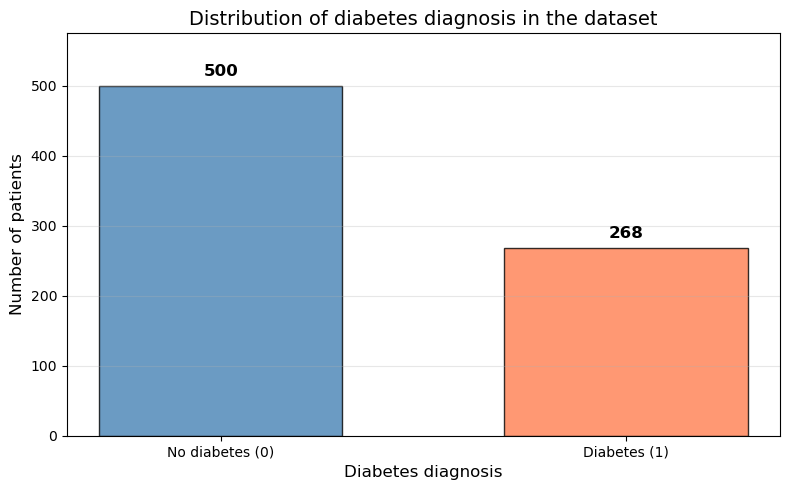


FIGURE 2: Bar chart of the target variable (diabetes)
Interpretation: The dataset is imbalanced — there are more patients without
diabetes than with diabetes. This has important consequences later!


In [9]:
# ============================================================================
# HISTOGRAM OF THE TARGET VARIABLE
# ============================================================================

fig, ax = plt.subplots(figsize=(8, 5))

# Count observations in each class and plot a bar chart
class_counts = diabetes['diabetes'].value_counts().sort_index()
colors = ['steelblue', 'coral']
bars = ax.bar(
    x=[0, 1],
    height=class_counts.values,
    color=colors,
    edgecolor='black',
    alpha=0.8,
    width=0.6,
)

# Add counts above each bar
for bar, count in zip(bars, class_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        str(count),
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold',
    )

ax.set_xlabel('Diabetes diagnosis', fontsize=12)
ax.set_ylabel('Number of patients', fontsize=12)
ax.set_title('Distribution of diabetes diagnosis in the dataset', fontsize=14)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No diabetes (0)', 'Diabetes (1)'])
ax.set_ylim(0, max(class_counts.values) * 1.15)  # Room for text above bars
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nFIGURE 2: Bar chart of the target variable (diabetes)")
print("Interpretation: The dataset is imbalanced — there are more patients without")
print("diabetes than with diabetes. This has important consequences later!")

### Description of the features

Here is a description of each variable in the dataset (from [Kaggle](https://www.kaggle.com/uciml/pima-indians-diabetes-database)):

| Variable | Description |
|----------|-------------|
| **Pregnancies** | Number of pregnancies |
| **Glucose** | Plasma glucose concentration 2 hours into an oral glucose tolerance test |
| **BloodPressure** | Diastolic blood pressure (mm Hg) |
| **SkinThickness** | Triceps skin fold thickness (mm) |
| **Insulin** | 2-hour serum insulin (μU/ml) |
| **BMI** | Body Mass Index (weight in kg / (height in m)²) |
| **DiabetesPedigreeFunction** | Diabetes pedigree function (genetic predisposition) |
| **Age** | Age (years) |
| **diabetes** | Target variable: 0 = no diabetes, 1 = diabetes |

### Prepare data for machine learning

In machine learning, we call:
- **X**: The features — what we use to make predictions
- **y**: The labels — what we want to predict

We want to approximate the function that maps from X to y:

$$y \approx f(X; \theta)$$

where θ represents the model parameters learned from data.

In [10]:
# ============================================================================
# SEPARATE FEATURES (X) AND LABELS (y)
# ============================================================================

# X: All columns except 'diabetes' (the features)
X = diabetes.drop('diabetes', axis=1)

# y: Only the 'diabetes' column (the labels)
y = diabetes['diabetes']

print("✓ Data separated!")
print(f"  X (features): {X.shape[0]} rows, {X.shape[1]} columns")
print(f"  y (labels): {len(y)} values")

✓ Data separated!
  X (features): 768 rows, 8 columns
  y (labels): 768 values


In [11]:
# Show the first features
X.head()

,pregnancies,glucose,diastolic,triceps,insulin,bmi,dpf,age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [12]:
# Show the first labels
y.head()

0    1
1    0
2    1
3    0
4    1
Name: diabetes, dtype: int64

---

# Split the data into training and test sets

## 🎯 Why split the data? The most important insight!

This is perhaps the **most important concept** you will learn in this course:

> ⚠️ **The golden rule of machine learning:** We must ALWAYS evaluate the model on data it did NOT see during training.

### The problem: overfitting versus generalization

Imagine a student who memorizes past exam solutions word-for-word without understanding the concepts. On a test with exactly the same questions, the student scores 100%. But on a new exam with slightly different questions, the student fails completely (i.e., the learning/memorization does not generalize).

A machine learning model can do the same — it can "memorize" the training data instead of learning the underlying patterns. This is called **overfitting** and usually leads to poor **generalization**.

### The test set: our "exam"

The test set is used **only** for final evaluation. We must never:
- Use test data during training
- Choose model parameters based on test results
- "Peek" at the test data during model development

> 📚 **Analogy:** The test set is like an exam. You do not get to see the questions in advance.

<img src="figures/training_test_split.png" width="60%">

**Figure 3: Simple dataset split.** *We split all available data into a training set (light gray, ~75%) and a test set (dark gray, ~25%). <br>The training set is used to learn, the test set simulates "new, unseen data" and is used only for final evaluation.*

<details>
<summary>🔍 <b>Python code that generated the figure</b> (click to expand)</summary>

The figure is generated with `figures/generate_figures.py`. You can regenerate it like this:

```python
from figures.generate_figures import plot_training_test_split
fig, ax = plot_training_test_split(save=True)
plt.show()
```

The function draws:
- Two rounded boxes: Training set (light gray) and Test set (dark gray)
- Proportions: 75% training, 25% test
- An "All available data" line with labels

To see the full code, open the file `figures/generate_figures.py`.

</details>

We randomly split 25% of the data into the test set:

In [13]:
# ============================================================================
# SPLIT DATA INTO TRAINING AND TEST SETS
# ============================================================================

from sklearn.model_selection import train_test_split

# Split data: 75% training, 25% test
# random_state ensures reproducible results
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,      # 25% for test
    random_state=42,     # For reproducibility
)

print("✓ Data split!")
print(f"  Training set: {len(X_train)} observations")
print(f"  Test set: {len(X_test)} observations")

✓ Data split!
  Training set: 576 observations
  Test set: 192 observations


In [14]:
# Verify the number of observations
print(f"Training set: {len(X_train)}, Test set: {len(X_test)}")

Training set: 576, Test set: 192


---

# Train a classification model

Now we will train our first classification model. We have many algorithms to choose from. For now, we use `SGDClassifier` — a linear classifier optimized with stochastic gradient descent.

> 💡 **Note:** For now we use the model as a "black box". The focus is on classification in general, not on the internal details of this specific algorithm. Feel free to read more about the model [here](http://scikit-learn.org/stable/modules/sgd.html) if you’re curious.

<details>
<summary>🔍 <b>For the curious: how does SGDClassifier work?</b> (click to expand)</summary>

### Short explanation of SGDClassifier

#### Intuition first — without math 🎯

Imagine you want to learn to separate diabetes patients from healthy individuals. You have a large sheet where all patients are plotted as points, where the position depends on their measurements (blood glucose, BMI, age, etc.). Diabetes patients are red dots, healthy ones are blue.

**What does SGDClassifier do?**

1. **Draw a line:** The model tries to draw a straight line (or a "plane" in higher dimensions) that separates the red from the blue points as well as possible.

2. **Start randomly:** First it draws a random line — which is likely quite poor.

3. **Learn from mistakes:** It picks one random patient and checks: "Did this one end up on the correct side of the line?"
   - If yes: Great, move on.
   - If no: Adjust the line slightly so this patient ends up on the correct side.

4. **Repeat many times:** By doing this thousands of times with random patients, the line gradually becomes better and better.

> 🏔️ **Analogy:** Imagine standing on a mountain in dense fog and wanting to get down to the valley. You can’t see the valley, but you can feel the slope under your feet. SGD says: "Take a small step in the direction that goes downhill." Do this many times and you end up in the valley — even without seeing the whole landscape.

**Why "stochastic"?** Because it picks random ("stochastic") examples instead of looking at all of them at once. That makes it fast, but also a bit "jumpy" during learning.

---

#### The mathematical explanation 📐

**SGD** stands for **Stochastic Gradient Descent**. Let’s break it down.

#### 1. Linear classifier
SGDClassifier is a *linear* model. It finds a **hyperplane** (a straight line in 2D, a plane in 3D, etc.) that separates the two classes as well as possible:

$$\hat{y} = \text{sign}(\mathbf{w}^T \mathbf{x} + b)$$

where:
- $\mathbf{w}$ is a vector of weights (one per feature)
- $\mathbf{x}$ is the data point (feature values)
- $b$ is a bias term (intercept)
- $\text{sign}()$ yields +1 or -1 depending on whether the value is positive or negative

#### 2. Loss function
The model defines a **loss function** that measures how poorly it is doing. A common default for SGDClassifier is "hinge loss" (as in Support Vector Machines):

$$L(y, \hat{y}) = \max(0, 1 - y \cdot \hat{y})$$

This yields 0 loss if the prediction is correct with a good margin, and increasing loss otherwise.

#### 3. Stochastic gradient descent
Instead of computing the gradient on *all* data (expensive), SGD uses **one random data point at a time**:

```
For each epoch (one pass through the data):
    For each random data point (x_i, y_i):
        1. Compute prediction: ŷ = sign(w·x_i + b)
        2. Compute loss: L = max(0, 1 - y_i·ŷ)
        3. Update weights: w ← w - η·∇L
```

where $\eta$ is the learning rate (how large the steps are).

#### Advantages of SGDClassifier
- ✅ **Scales well:** Handles millions of data points
- ✅ **Fast training:** One pass through the data can be enough
- ✅ **Online learning:** Can be updated with new data without full retraining
- ✅ **Flexible:** Supports different loss functions (log loss, hinge, etc.)

#### Disadvantages
- ❌ **Sensitive to scaling:** Works best with normalized data
- ❌ **Hyperparameters:** Learning rate and regularization must be tuned
- ❌ **Only linear:** Cannot learn complex non-linear patterns

#### Illustration

```
Class 0: ●●●●●●                    Hyperplane (decision boundary)
                    \                      ↓
                     \           ──────────────────
                      \         /
Class 1:              ○○○○○○○○

SGDClassifier finds the optimal line that separates the classes.
```

> 📚 **Further reading:** [scikit-learn SGD documentation](https://scikit-learn.org/stable/modules/sgd.html)

</details>

In [15]:
# ============================================================================
# IMPORT AND CREATE A CLASSIFICATION MODEL
# ============================================================================

from sklearn.linear_model import SGDClassifier

# Create an instance of the model
# random_state ensures reproducible results
sgd_clf = SGDClassifier(random_state=20)

print("✓ SGDClassifier created!")

✓ SGDClassifier created!


In [16]:
# ============================================================================
# TRAIN THE MODEL
# ============================================================================

# fit() trains the model on the training data
# This is where the "magic" happens — the model learns patterns from data
sgd_clf.fit(X_train, y_train)

print("✓ The model has been trained on the training data!")

✓ The model has been trained on the training data!


With the model trained, we can now make predictions on the test set:

In [17]:
# ============================================================================
# MAKE PREDICTIONS ON THE TEST SET
# ============================================================================

# predict() gives the model's prediction for each observation
y_pred = sgd_clf.predict(X_test)

# Show the first 20 predictions
print("The first 20 predictions:")
print(y_pred[:20])

The first 20 predictions:
[1 0 0 0 0 1 1 1 1 0 1 1 1 1 0 1 0 1 1 1]


Here are the true labels for the first 20 observations:

In [18]:
# Show the true labels
print("True labels (first 20):")
print(np.array(y_test)[:20])

True labels (first 20):
[0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 1 1]


Let’s compare predictions with true values:

In [19]:
# ============================================================================
# COMPARE PREDICTIONS WITH TRUE VALUES
# ============================================================================

print("Comparison: (True, Predicted)")
print("=" * 50)
results = list(zip(y_test, y_pred))[:20]
for i, (actual, predicted) in enumerate(results, 1):
    status = "✓" if actual == predicted else "✗"
    print(f"  {i:2d}. ({actual}, {predicted}) {status}")

Comparison: (True, Predicted)
   1. (0, 1) ✗
   2. (0, 0) ✓
   3. (0, 0) ✓
   4. (0, 0) ✓
   5. (0, 0) ✓
   6. (0, 1) ✗
   7. (0, 1) ✗
   8. (0, 1) ✗
   9. (0, 1) ✗
  10. (0, 0) ✓
  11. (1, 1) ✓
  12. (0, 1) ✗
  13. (1, 1) ✓
  14. (0, 1) ✗
  15. (0, 0) ✓
  16. (1, 1) ✓
  17. (0, 0) ✓
  18. (0, 1) ✗
  19. (1, 1) ✓
  20. (1, 1) ✓


We see that the model is correct sometimes, and wrong other times.

> 🤔 **But how good is the model really?** We need ways to evaluate and validate models...

---

# Model evaluation: performance metrics

Before we dive into metrics and methods, it is important to ask: "What is the end goal of our system?"

Different contexts require different trade-offs:
- Sometimes we sacrifice accuracy for speed
- In medical contexts, certain types of errors can be more serious than others

For now, we focus on the fundamental evaluation methods.

## Accuracy and different types of errors

**Accuracy** is the fraction of correct predictions — often the first metric we look at.

But in binary classification, there are different types of errors:

| Type | Abbreviation | Meaning |
|------|--------------|---------|
| **True positive** | TP | Correctly identified as positive (sick) |
| **False positive** | FP | Incorrectly classified as positive (healthy, but diagnosed as sick) |
| **True negative** | TN | Correctly identified as negative (healthy) |
| **False negative** | FN | Incorrectly classified as negative (sick, but not detected) |

> ⚠️ **Important in medicine:** These error types can have very different consequences!
> - **False negative** (FN): A sick patient does not receive treatment → potentially dangerous
> - **False positive** (FP): A healthy patient receives unnecessary treatment → resource use and anxiety

We can compute accuracy with `accuracy_score` from scikit-learn:

In [20]:
# ============================================================================
# COMPUTE ACCURACY
# ============================================================================

from sklearn.metrics import accuracy_score

# Compute accuracy: fraction of correct predictions
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy on the test set: {accuracy:.1%}")
print(f"  ({accuracy*100:.1f}% of the predictions are correct)")

Accuracy on the test set: 54.2%
  (54.2% of the predictions are correct)


The model predicts correctly about 54% of the time. Is that good?

Let’s look at this more closely...

## Validation set and model selection

**Model selection** is the process of choosing the best model and tuning its parameters.

> ⚠️ **Critical:** We must avoid using the test set during model selection. Otherwise information "leaks", and we get a biased estimate of generalization performance.

Instead, we split the training data into:
1. **Training set** (new, smaller): to train the model
2. **Validation set**: to evaluate during model development

<img src="figures/dataset_split.png" width="70%">

**Figure 4: Splitting a dataset into training, validation, and test sets.** *The dataset 𝒟 is first split into a training set (white) and a test set (dark pink). <br>The training set is then split further into a smaller training set and a validation set (light pink) for model selection and hyperparameter tuning. <br>The test set is kept completely separate and is used only for final evaluation.*

<details>
<summary>🔍 <b>Python code that generated the figure</b> (click to expand)</summary>

The figure is generated with `figures/generate_figures.py`. You can regenerate it like this:

```python
from figures.generate_figures import plot_dataset_split
fig, ax = plot_dataset_split(save=True)
plt.show()
```

To see the full code, open the file `figures/generate_figures.py`.

</details>

### Your Turn! 🎯

- Split `(X_train, y_train)` into two parts: a new training set and a validation set. You can call them `X_train_new, X_val, y_train_new, y_val`. *Hint:* Use `train_test_split`.
- Train the model on the new training set
- Compute accuracy on the validation set with `model.score(X_val, y_val)`
- Is the result good? What accuracy would a random classifier achieve?
- Experiment with parameters in `SGDClassifier` to improve the result

<details>
<summary>Click <font color="red"><b>here</b></font> for a solution</summary>

```python
from sklearn.model_selection import train_test_split

# Split training data into a new training set and a validation set
X_train_new, X_val, y_train_new, y_val = train_test_split(X_train, y_train)

# Train the model on the new training set
model = SGDClassifier(random_state=20)
model.fit(X_train_new, y_train_new)

# Evaluate on the validation set
print(f"Accuracy on validation set: {model.score(X_val, y_val):.1%}")
```

</details>

---

## Cross-validation

Another widely used validation method is **cross-validation**.

### The idea behind cross-validation

1. Randomly split the training set into K parts, called **folds**
2. Train the model K times, each time using one fold as the validation set and the remaining K−1 folds as the training set
3. Use the average of the K scores as a performance estimate

<img src="figures/kfold_balls.png" width="85%">

**Figure 5: K-fold cross-validation with k=4.** *Each row shows one iteration. The colored circles represent individual data points. In each iteration, one fold (marked with a frame) is used as test data, while the rest is used for training. After k iterations, each data point has been used as test data exactly once.*

<details>
<summary>🔍 <b>Python code that generated the figure</b> (click to expand)</summary>

The figure is generated with `figures/generate_figures.py`. You can regenerate it like this:

```python
from figures.generate_figures import plot_kfold_cross_validation_balls
fig, ax = plot_kfold_cross_validation_balls(k=4, n_datapoints=20, save=True)
plt.show()
```

The function draws:
- Colored circles (red/teal) representing data points
- A 3D effect on the circles (highlights and shadows)
- A frame around the test fold that moves each iteration
- Text boxes and arrows with Norwegian labels

To see the full code, open the file `figures/generate_figures.py`.

</details>

### Advantages of cross-validation

1. **Uses data more efficiently:** Each data point is used for both training and validation
2. **More robust estimate:** Less dependent on a particular random split
3. **Reduces variance:** The mean of K measurements is more stable

> 📚 **Special case:** When K equals the number of data points, it is called "leave-one-out" cross-validation.

In [21]:
# ============================================================================
# 5-FOLD CROSS-VALIDATION
# ============================================================================

from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation
# cv=5: Split into 5 folds
# scoring='accuracy': Use accuracy as the metric
# n_jobs=-1: Use all available CPU cores
cv_scores = cross_val_score(
    sgd_clf,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
)

print("Cross-validation results:")
print("=" * 50)
print(f"  Score for each fold: {cv_scores}")
print(f"  Mean accuracy: {cv_scores.mean():.1%}")
print(f"  Standard deviation: {cv_scores.std():.3f}")

Cross-validation results:
  Score for each fold: [0.62068966 0.55652174 0.34782609 0.65217391 0.68695652]
  Mean accuracy: 57.3%
  Standard deviation: 0.120


### Is 57% accuracy good?

The mean accuracy of about 57% may sound okay. But let’s check:

Remember that there were **more non-diabetes than diabetes** cases in the dataset.

In [22]:
# ============================================================================
# CHECK THE CLASS DISTRIBUTION
# ============================================================================

# Count the number in each class
class_counts = diabetes['diabetes'].value_counts()
print("Class distribution in the dataset:")
print(class_counts)
print(f"\nProportion no diabetes: {class_counts[0]/len(diabetes):.1%}")
print(f"Proportion diabetes: {class_counts[1]/len(diabetes):.1%}")

Class distribution in the dataset:
diabetes
0    500
1    268
Name: count, dtype: int64

Proportion no diabetes: 65.1%
Proportion diabetes: 34.9%


What if we simply guess that **everyone** belongs to the majority class (no diabetes)?

In [23]:
# ============================================================================
# COMPARE AGAINST A NAIVE BASELINE
# ============================================================================

# Create a "prediction" where we always say 0 (no diabetes)
y_dummy = [0] * len(y_test)  # List of zeros only

# Compute accuracy
dummy_accuracy = accuracy_score(y_test, y_dummy)
print(f"Accuracy when always guessing 'no diabetes': {dummy_accuracy:.1%}")
print(f"\nOur model achieved: {accuracy_score(y_test, y_pred):.1%}")
print(f"Difference: {accuracy_score(y_test, y_pred) - dummy_accuracy:.1%}")

Accuracy when always guessing 'no diabetes': 64.1%

Our model achieved: 54.2%
Difference: -9.9%


### ⚠️ The pitfall of imbalanced datasets

This illustrates a **critical point**: In datasets where one class dominates, a naive classifier that always chooses the majority class can achieve high accuracy.

> 📚 **Lesson:** Accuracy alone is often misleading. We need other metrics to understand the model’s true performance.

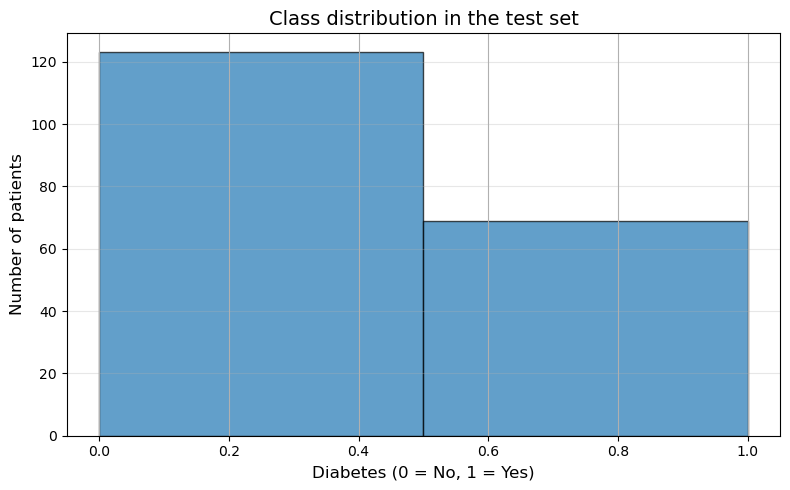


FIGURE 6: Class distribution in the test set
Interpretation: The test set also has an imbalanced class distribution.
This makes accuracy a problematic metric.


In [24]:
# ============================================================================
# SHOW CLASS DISTRIBUTION IN THE TEST SET
# ============================================================================

fig, ax = plt.subplots(figsize=(8, 5))
y_test.hist(bins=2, ax=ax, edgecolor='black', alpha=0.7)
ax.set_xlabel('Diabetes (0 = No, 1 = Yes)', fontsize=12)
ax.set_ylabel('Number of patients', fontsize=12)
ax.set_title('Class distribution in the test set', fontsize=14)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nFIGURE 6: Class distribution in the test set")
print("Interpretation: The test set also has an imbalanced class distribution.")
print("This makes accuracy a problematic metric.")

### Your Turn! 🎯

Many machine learning models, including `SGDClassifier`, perform better when inputs are **scaled**.

Try using `StandardScaler` from scikit-learn to standardize the training data. Then run `cross_val_score` on the scaled data.

```python
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Hint: Create a scaler, use fit_transform on the training data
# and transform on the test data
```

---

## Confusion matrix

A **confusion matrix** summarizes the results from a classification model. It shows in what ways the classifier is "confused" — which mistakes it makes.

The matrix counts how many times:
- Diabetes cases are correctly identified as diabetes
- Non-diabetes cases are correctly identified as non-diabetes
- Diabetes cases are incorrectly classified as non-diabetes
- Non-diabetes cases are incorrectly classified as diabetes

In [25]:
# ============================================================================
# GENERATE PREDICTIONS WITH CROSS-VALIDATION
# ============================================================================

from sklearn.model_selection import cross_val_predict

# cross_val_predict returns predictions for all data
# based on cross-validation (each prediction is made
# when the observation was in the validation fold)
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train, cv=5, n_jobs=-1)

print(f"✓ Generated {len(y_train_pred)} predictions")

✓ Generated 576 predictions


In [26]:
# Show the first predictions
print("The first 20 predictions:")
print(y_train_pred[:20])

The first 20 predictions:
[1 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 0]


In [27]:
# Show the true values
print("True values (first 20):")
print(np.array(y_train)[:20])

True values (first 20):
[1 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 1 1 0 0]


In [28]:
# ============================================================================
# COMPUTE THE CONFUSION MATRIX
# ============================================================================

from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(y_train, y_train_pred)

print("Confusion Matrix:")
print(cm)
print("\nInterpretation:")
print("  Row 1: True non-diabetes (class 0)")
print("  Row 2: True diabetes (class 1)")
print("  Column 1: Predicted as non-diabetes")
print("  Column 2: Predicted as diabetes")

Confusion Matrix:
[[226 151]
 [ 95 104]]

Interpretation:
  Row 1: True non-diabetes (class 0)
  Row 2: True diabetes (class 1)
  Column 1: Predicted as non-diabetes
  Column 2: Predicted as diabetes


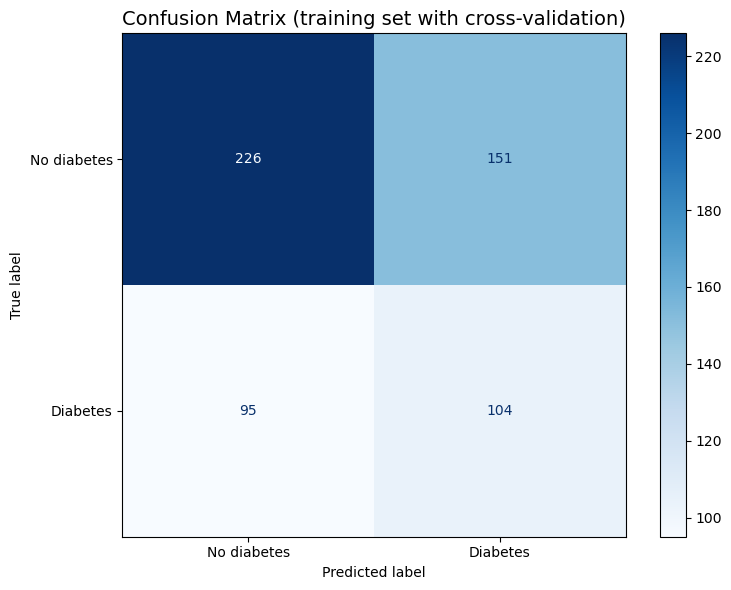


FIGURE 7: Confusion Matrix
Interpretation: Color intensity shows the number of observations in each category.
Ideally, we want large numbers on the diagonal (correct predictions)
and small numbers off the diagonal (errors).


In [29]:
# ============================================================================
# VISUALIZE THE CONFUSION MATRIX
# ============================================================================

from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_train,
    y_train_pred,
    display_labels=['No diabetes', 'Diabetes'],
    cmap='Blues',
    ax=ax,
)
ax.set_title('Confusion Matrix (training set with cross-validation)', fontsize=14)
plt.tight_layout()
plt.show()

print("\nFIGURE 7: Confusion Matrix")
print("Interpretation: Color intensity shows the number of observations in each category.")
print("Ideally, we want large numbers on the diagonal (correct predictions)")
print("and small numbers off the diagonal (errors).")

### Interpreting the confusion matrix

Each row represents a **true class**, and each column a **predicted class**:

| | Predicted: No diabetes | Predicted: Diabetes |
|---|---|---|
| **True: No diabetes** | True negative (TN) | False positive (FP) |
| **True: Diabetes** | False negative (FN) | True positive (TP) |

From our matrix we see:
- **True negatives (TN)**: Correctly classified as no diabetes
- **False positives (FP)**: Incorrectly classified as diabetes (actually healthy)
- **False negatives (FN)**: Incorrectly classified as no diabetes (actually sick)
- **True positives (TP)**: Correctly classified as diabetes

> 🤔 **Reflection:** What would the confusion matrix look like for a *perfect* classifier?

---

## Precision, recall, and specificity

For binary classification problems, three important metrics are **precision**, **recall** (sensitivity), and **specificity**.

### Notation

| Symbol | Meaning |
|--------|---------|
| P | All truly positive data points |
| N | All truly negative data points |
| TP | True positives (correctly identified positives) |
| FP | False positives (negatives incorrectly identified as positives) |
| TN | True negatives (correctly identified negatives) |
| FN | False negatives (positives incorrectly identified as negatives) |

### Precision

**Precision** is the fraction of positive predictions that are actually correct.

$$\text{Precision} = \frac{\text{True positives}}{\text{All positive predictions}} = \frac{TP}{TP + FP}$$

> 📚 **Intuition:** "When the model says 'diabetes', how often is it right?"

> 🏥 **Medical relevance:** High precision means fewer false alarms — fewer healthy patients receive an unnecessary diagnosis.

### Recall / Sensitivity

**Recall** (also called sensitivity) is the fraction of truly positive cases that are correctly identified.

$$\text{Recall} = \frac{\text{True positives}}{\text{All truly positive}} = \frac{TP}{TP + FN}$$

> 📚 **Intuition:** "Of all those who actually have diabetes, how many does the model catch?"

> 🏥 **Medical relevance:** High recall means we catch most sick patients — important for serious diseases where we do not want to miss anyone.

### Specificity

**Specificity** is the fraction of truly negative cases that are correctly identified.

$$\text{Specificity} = \frac{\text{True negatives}}{\text{All truly negative}} = \frac{TN}{TN + FP}$$

> 📚 **Intuition:** "Of all those who are actually healthy, how many does the model correctly identify as healthy?"

> 🏥 **Medical relevance:** High specificity means fewer healthy people receive an incorrect diagnosis.

<img src="figures/sensitivity_specificity.png" width="55%">

**Figure 8: Illustration of sensitivity and specificity.** *The diagram shows the relationship between relevant elements (truly positive, green background), selected elements (predicted positive, oval), and the four outcomes: true positives (TP), false positives (FP), false negatives (FN), and true negatives (TN). Filled dots represent truly sick cases; empty dots represent truly healthy cases. Sensitivity measures how many sick cases are caught; specificity measures how many healthy cases are correctly identified.*

<details>
<summary>🔍 <b>Python code that generated the figure</b> (click to expand)</summary>

The figure is generated with `figures/generate_figures.py`. You can regenerate it like this:

```python
from figures.generate_figures import plot_sensitivity_specificity
fig, ax = plot_sensitivity_specificity(save=True)
plt.show()
```

The function draws:
- Two halves: green (true positives) and gray (true negatives)
- An oval representing predicted positives (selected elements)
- Four regions: TP, FP, FN, TN with color coding
- Filled dots (sick) and empty dots (healthy) as data points
- Explanations and formulas for sensitivity and specificity

To see the full code, open the file `figures/generate_figures.py`.

</details>

### Connection to the confusion matrix

The confusion matrix gives us the values TP, FP, FN, and TN that we need to compute the metrics:

In [30]:
# ============================================================================
# COMPUTE METRICS FROM THE CONFUSION MATRIX
# ============================================================================

# Extract values from the confusion matrix
# ravel() flattens the matrix into a 1D array
tn, fp, fn, tp = cm.ravel()

print("Values from the confusion matrix:")
print(f"  True negatives (TN): {tn}")
print(f"  False positives (FP): {fp}")
print(f"  False negatives (FN): {fn}")
print(f"  True positives (TP): {tp}")

Values from the confusion matrix:
  True negatives (TN): 226
  False positives (FP): 151
  False negatives (FN): 95
  True positives (TP): 104


In [31]:
# ============================================================================
# COMPUTE PRECISION, RECALL, AND SPECIFICITY
# ============================================================================

# Precision: fraction correct among predicted positives
precision = tp / (tp + fp)

# Recall: fraction detected among truly positives
recall = tp / (tp + fn)

# Specificity: fraction correct among truly negatives
specificity = tn / (tn + fp)

print("Computed metrics:")
print("=" * 50)
print(f"  Precision:    {precision:.3f} ({precision:.1%})")
print(f"  Recall:       {recall:.3f} ({recall:.1%})")
print(f"  Specificity:  {specificity:.3f} ({specificity:.1%})")

Computed metrics:
  Precision:    0.408 (40.8%)
  Recall:       0.523 (52.3%)
  Specificity:  0.599 (59.9%)


scikit-learn has built-in functions for these computations:

In [32]:
# ============================================================================
# USE SCIKIT-LEARN FUNCTIONS
# ============================================================================

from sklearn.metrics import precision_score, recall_score

# Compute with scikit-learn
print("Metrics from scikit-learn:")
print(f"  Precision: {precision_score(y_train, y_train_pred):.3f}")
print(f"  Recall:    {recall_score(y_train, y_train_pred):.3f}")

Metrics from scikit-learn:
  Precision: 0.408
  Recall:    0.523


### Your Turn! 🎯

> 🤔 **Reflection:** What matters most — high precision or high recall?

Consider different medical scenarios:
1. Screening for a rare but deadly disease
2. Testing for a mild condition where treatment has side effects
3. Diagnosing an infectious disease

Which metric would you prioritize in each case, and why?

---

## F₁-score

Since we often care about both precision and recall, it can be useful to combine them into a single metric.

The **F₁ score** is the harmonic mean of precision and recall:

$$F_1 = \frac{2}{\frac{1}{\text{precision}} + \frac{1}{\text{recall}}} = 2 \cdot \frac{\text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}$$

### Why the harmonic mean?

The harmonic mean becomes low if either precision or recall is low. This penalizes classifiers that "cheat" by focusing on only one of the two.

> 📚 **Example:** If precision = 0.0001 and recall = 1.0:
> - Arithmetic mean: (0.0001 + 1) / 2 ≈ 0.5 (sounds good!)
> - F₁ score: ≈ 0.0002 (reveals the poor performance)

An F₁ score of 1.0 means perfect precision **and** perfect recall.

In [33]:
# ============================================================================
# COMPUTE F1 SCORE
# ============================================================================

from sklearn.metrics import f1_score

f1 = f1_score(y_train, y_train_pred)

print(f"F₁ score: {f1:.3f}")
print(f"\nInterpretation: An F₁ score of {f1:.2f} indicates moderate performance.")
print("A perfect classifier would have F₁ = 1.0")

F₁ score: 0.458

Interpretation: An F₁ score of 0.46 indicates moderate performance.
A perfect classifier would have F₁ = 1.0


### Your Turn! 🎯

Two classifiers A and B have the following values:

$$
\begin{align}
\text{precision}_A = 0.7,\quad &\text{recall}_A = 0.6 \\
\text{precision}_B = 0.3,\quad &\text{recall}_B = 1.0
\end{align}
$$

1. Compute the arithmetic mean for both models
2. Compute the F₁ score for both models
3. Which model is best according to F₁?

### Your Turn! 🎯

Remember that I asked you to try normalizing the data with `StandardScaler`? If you haven’t done it yet, try it now, and then run the predictions through the evaluation methods above.

Here is a solution. Don’t look before you’ve tried it yourself.

In [34]:
# ============================================================================
# SOLUTION: NORMALIZATION AND EVALUATION
# ============================================================================

if (colab):
    import urllib.request
    from urllib.error import HTTPError

    # Download the solution script
    url = 'https://raw.githubusercontent.com/MMIV-ML/BMED365-2025/master/Lab0-ML/notebooks/solutions/1.3-1-sgd_normalized.py'
    filename = '1.3-1-sgd_normalized.py'

    try:
        urllib.request.urlretrieve(url, filename)
        print(f"✓ Downloaded {filename}")
    except HTTPError as e:
        print(f"✗ Could not download {filename}: {e}")

    # Load the script
    filepath = os.path.join(os.getcwd(), filename)
    %load {filepath}

In [35]:
# %load /Users/arvid/GitHub/BMED365-2026/Lab0-ML/notebooks/solutions/1.3-1-sgd_normalized.py
from sklearn.preprocessing import StandardScaler

# Create an instance of the StandardScaler
scaler = StandardScaler()

# Fit and transform the training and test data using the scaler
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train an SGDClassifier
sgd_clf_scaled = SGDClassifier(random_state=20)
sgd_clf_scaled.fit(X_train_scaled, y_train)

# Compute the cross-validation predictions on the scaled training set
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=5)

# Print the accuracy, confusion matrix, and F1 score
print("Cross-validation results on the scaled training set:")
print(f"Accuracy: {accuracy_score(y_train, y_train_pred)}")
print(f"Confusion matrix:\n{confusion_matrix(y_train, y_train_pred)}")
print(f"F1 score: {f1_score(y_train, y_train_pred)}")


Cross-validation results on the scaled training set:
Accuracy: 0.6996527777777778
Confusion matrix:
[[287  90]
 [ 83 116]]
F1 score: 0.5728395061728395


In [36]:
# ============================================================================
# NORMALIZATION WITH STANDARD SCALER
# ============================================================================

from sklearn.preprocessing import StandardScaler

# Create a StandardScaler
scaler = StandardScaler()

# Fit on the training data and transform
# fit_transform learns the parameters (mean, std) and transforms
X_train_scaled = scaler.fit_transform(X_train)

# Use transform only on the test data (to avoid data leakage)
X_test_scaled = scaler.transform(X_test)

# Train a new SGDClassifier on scaled data
sgd_clf_scaled = SGDClassifier(random_state=20)
sgd_clf_scaled.fit(X_train_scaled, y_train)

# Evaluate with cross-validation
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=5)

# Print results
print("Cross-validation on scaled data:")
print("=" * 50)
print(f"  Accuracy: {accuracy_score(y_train, y_train_pred):.1%}")
print("  Confusion Matrix:")
print(confusion_matrix(y_train, y_train_pred))
print(f"  F₁ score: {f1_score(y_train, y_train_pred):.3f}")

Cross-validation on scaled data:
  Accuracy: 70.0%
  Confusion Matrix:
[[287  90]
 [ 83 116]]
  F₁ score: 0.573


We continue using the normalized classifier:

In [37]:
# ============================================================================
# UPDATE VARIABLES TO SCALED VERSIONS
# ============================================================================

sgd_clf = sgd_clf_scaled
X_train = X_train_scaled
X_test = X_test_scaled

print("✓ Updated to scaled data and model")

✓ Updated to scaled data and model


---

## The precision/recall trade-off

It is typically difficult to achieve both high precision and high recall at the same time. Improving one can worsen the other. This trade-off is due to the **threshold** used to make classification decisions.

### Why does this trade-off exist?

A classifier with perfect recall is easy to make: just predict that **everything** is positive. Then there are no false negatives, and recall = 1.0. But precision will be terrible.

To achieve high precision, do the opposite: predict positive only when you are **extremely sure**. Then there will be few false positives, but many false negatives, so recall becomes poor.

### What happens "behind the scenes"?

When we train `SGDClassifier`, it finds a **hyperplane** (a boundary) in the feature space that separates the classes as well as possible.

For each data point, the model computes the **distance** to this hyperplane:
- **Negative distance** → predicted as the negative class
- **Positive distance** → predicted as the positive class

The default threshold is 0, but we can change it.

> 💡 **Key insight:** Where you set the threshold has a major impact on precision and recall.

Let’s experiment with an example from the test set:

In [38]:
# ============================================================================
# INSPECT AN EXAMPLE
# ============================================================================

# Get the first test point
eksempel_features = X_test[0]
eksempel_faktisk = y_test.iloc[0]

print("Example data point (first in the test set):")
print(
    f"  True class: {eksempel_faktisk} ({'Diabetes' if eksempel_faktisk == 1 else 'No diabetes'})"
)

Example data point (first in the test set):
  True class: 0 (No diabetes)


In [39]:
# ============================================================================
# COMPUTE DISTANCE TO THE DECISION BOUNDARY
# ============================================================================

# decision_function gives the distance to the hyperplane
avstand = sgd_clf.decision_function([eksempel_features])

print(f"Distance to the decision boundary: {avstand[0]:.3f}")
print("\nInterpretation: A negative distance means the model leans toward 'no diabetes'")

Distance to the decision boundary: -1.757

Interpretation: A negative distance means the model leans toward 'no diabetes'


In [40]:
# ============================================================================
# EXPERIMENT WITH THRESHOLDS
# ============================================================================

print("Experiment with different thresholds:")
print("=" * 50)

for terskel in [0, -1, -2, -10]:
    prediksjon = avstand > terskel
    print(f"  Threshold = {terskel:3d}: Predicted diabetes? {prediksjon[0]}")

Experiment with different thresholds:
  Threshold =   0: Predicted diabetes? False
  Threshold =  -1: Predicted diabetes? False
  Threshold =  -2: Predicted diabetes? True
  Threshold = -10: Predicted diabetes? True


You can see that by **increasing the threshold** for classifying something as diabetes, the model becomes more "conservative" — fewer cases are predicted positive.

- **Higher threshold** → higher precision, lower recall
- **Lower threshold** → lower precision, higher recall

In [41]:
# ============================================================================
# COMPUTE DECISION SCORES FOR ALL TRAINING DATA
# ============================================================================

# Get decision scores for all training points using cross-validation
y_scores = cross_val_predict(
    sgd_clf,
    X_train,
    y_train,
    cv=2,
    method='decision_function',
)

print(f"✓ Computed {len(y_scores)} decision scores")
print(f"  Min score: {y_scores.min():.3f}")
print(f"  Max score: {y_scores.max():.3f}")

✓ Computed 576 decision scores
  Min score: -23.103
  Max score: 25.952


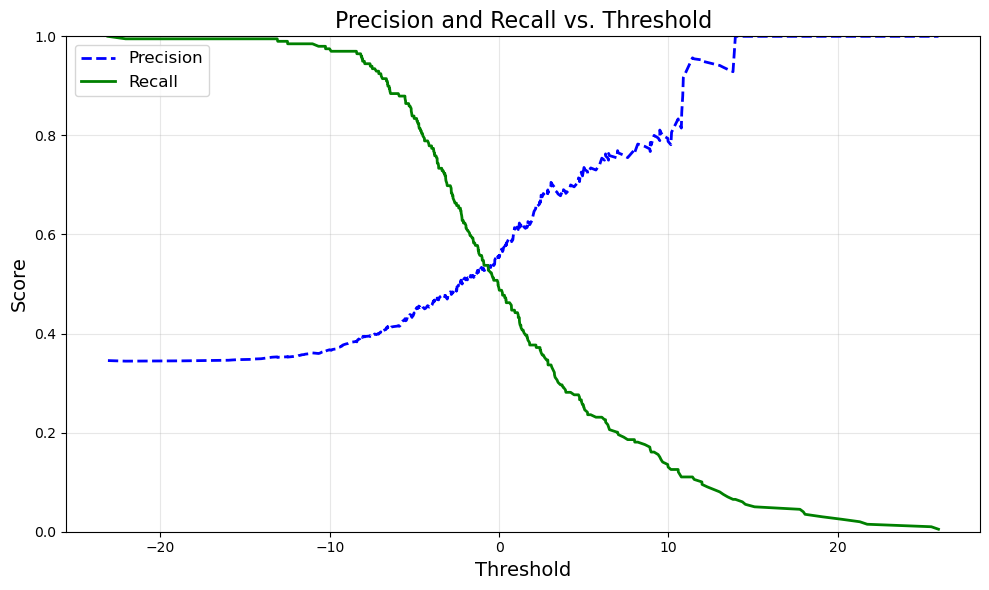


FIGURE 9: Precision and Recall as a function of the threshold
Interpretation: As the threshold increases, precision increases (blue dashed line)
while recall decreases (green line). This is the precision/recall trade-off.


In [42]:
# ============================================================================
# PLOT PRECISION/RECALL VS THRESHOLD
# ============================================================================

from sklearn.metrics import precision_recall_curve

# Compute precision and recall for different thresholds
presisjoner, recalls, terskler = precision_recall_curve(y_train, y_scores)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(terskler, presisjoner[:-1], "b--", label="Precision", linewidth=2)
ax.plot(terskler, recalls[:-1], "g-", label="Recall", linewidth=2)

ax.set_xlabel("Threshold", fontsize=14)
ax.set_ylabel("Score", fontsize=14)
ax.set_title("Precision and Recall vs. Threshold", fontsize=16)
ax.legend(loc="upper left", fontsize=12)
ax.set_ylim([0, 1])
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nFIGURE 9: Precision and Recall as a function of the threshold")
print("Interpretation: As the threshold increases, precision increases (blue dashed line)")
print("while recall decreases (green line). This is the precision/recall trade-off.")

### Choosing a threshold based on the problem

Where you set the threshold depends on the specific problem:

- **Spam filter:** High precision matters (we don’t want to lose important emails)
- **Cancer screening:** High recall matters (we don’t want to miss cases)

> 💡 **Important:** It’s easy to achieve almost any precision you want — just choose an appropriate threshold. But then you must also accept the corresponding recall value.

In [43]:
# ============================================================================
# EXAMPLE: ACHIEVE HIGH PRECISION
# ============================================================================

# Choose a high threshold for high precision
high_threshold = 18

y_pred_precise = (y_scores > high_threshold)

precision_high = precision_score(y_train, y_pred_precise)
recall_high = recall_score(y_train, y_pred_precise)

print(f"With threshold = {high_threshold}:")
print(f"  Precision: {precision_high:.1%}")
print(f"  Recall:    {recall_high:.1%}")
print("\nWe achieve high precision, but recall is very low.")

With threshold = 18:
  Precision: 100.0%
  Recall:    3.5%

We achieve high precision, but recall is very low.


> 📚 "If someone says 'let’s achieve 90% precision!', you should ask: 'with what recall?'"
> — Aurélien Géron

In [44]:
# ============================================================================
# F1 SCORE VS THRESHOLD (INTERACTIVE)
# ============================================================================

from ipywidgets import interact

@interact(terskel=(-20, 20, 1))
def vis_f1_score(terskel=0):
    """Show the F1 score for different thresholds."""
    f1_over = f1_score(y_train, (y_scores > terskel))
    f1_under = f1_score(y_train, (y_scores < terskel))
    print(f"Threshold: {terskel}")
    print(f"  F₁ (y_scores > threshold): {f1_over:.3f}")
    print(f"  F₁ (y_scores < threshold): {f1_under:.3f}")

interactive(children=(IntSlider(value=0, description='terskel', max=20, min=-20), Output()), _dom_classes=('wi…

---

## Comparing classifiers

Metrics like the F₁ score make it easy to compare different models. Let’s introduce a new classifier: **Random Forest**.

In [45]:
# ============================================================================
# TRAIN A RANDOM FOREST CLASSIFIER
# ============================================================================

from sklearn.ensemble import RandomForestClassifier

# Create and train Random Forest
# n_estimators: Number of trees in the forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Generate cross-validated predictions
y_train_pred_rf = cross_val_predict(rf_clf, X_train, y_train, cv=3)

print("✓ Random Forest trained and evaluated")
print(f"  Number of predictions: {len(y_train_pred_rf)}")

✓ Random Forest trained and evaluated
  Number of predictions: 576


In [46]:
# ============================================================================
# COMPARE F1 SCORES
# ============================================================================

# Compute F1 for both models
f1_sgd = f1_score(y_train, y_train_pred)
f1_rf = f1_score(y_train, y_train_pred_rf)

print("Comparison of F₁ scores:")
print("=" * 50)
print(f"  SGDClassifier:          {f1_sgd:.3f}")
print(f"  RandomForestClassifier: {f1_rf:.3f}")
print(f"\n  Winner: {'Random Forest' if f1_rf > f1_sgd else 'SGD'} (+{abs(f1_rf-f1_sgd):.3f})")

Comparison of F₁ scores:
  SGDClassifier:          0.573
  RandomForestClassifier: 0.625

  Winner: Random Forest (+0.052)


Let’s also compare the confusion matrices:

In [47]:
# ============================================================================
# COMPARE CONFUSION MATRICES
# ============================================================================

cm_rf = confusion_matrix(y_train, y_train_pred_rf)
cm_sgd = confusion_matrix(y_train, y_train_pred)

print("Confusion Matrix - Random Forest:")
print(cm_rf)

print("\nConfusion Matrix - SGDClassifier:")
print(cm_sgd)

# Compare specific values
print("\nDetailed comparison:")
print(f"  True positives  - RF: {cm_rf[1,1]}, SGD: {cm_sgd[1,1]}")
print(f"  False negatives - RF: {cm_rf[1,0]}, SGD: {cm_sgd[1,0]}")

Confusion Matrix - Random Forest:
[[323  54]
 [ 84 115]]

Confusion Matrix - SGDClassifier:
[[287  90]
 [ 83 116]]

Detailed comparison:
  True positives  - RF: 115, SGD: 116
  False negatives - RF: 84, SGD: 83


### Computation time

Another important consideration is **computation time**. Faster models may be preferable in production systems:

In [48]:
# ============================================================================
# COMPARE COMPUTATION TIME
# ============================================================================

print("Cross-validation computation time:")
print("=" * 50)

# Time Random Forest
%time rf_score = cross_val_score(rf_clf, X_train, y_train, cv=3).mean()
print(f"  Random Forest accuracy: {rf_score:.3f}")

# Time SGD
%time sgd_score = cross_val_score(sgd_clf, X_train, y_train, cv=3).mean()
print(f"  SGDClassifier accuracy: {sgd_score:.3f}")

print("\nComment: SGDClassifier is typically much faster!")

Cross-validation computation time:
CPU times: user 153 ms, sys: 3.08 ms, total: 156 ms
Wall time: 156 ms
  Random Forest accuracy: 0.760
CPU times: user 3.66 ms, sys: 34 μs, total: 3.69 ms
Wall time: 3.69 ms
  SGDClassifier accuracy: 0.719

Comment: SGDClassifier is typically much faster!


### Trade-offs in model selection

Random Forest may score better on F₁, but it is slower. Depending on the application, this can affect the choice:

- **Speed critical** (e.g., real-time system): SGD may be better
- **Accuracy critical** (e.g., screening): Random Forest may be worth the wait

> 💡 There is no single "best" model — it depends on the context.

---

# Final evaluation on the test set

After all experiments, we perform a final performance evaluation on the test set. This gives our best estimate of the model’s generalization performance.

In [49]:
# ============================================================================
# FINAL EVALUATION ON THE TEST SET
# ============================================================================

# Train Random Forest on the full training set
rf_clf_final = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf_final.fit(X_train, y_train)

# Evaluate on the test set
test_accuracy = rf_clf_final.score(X_test, y_test)

print("Final evaluation - Random Forest on the test set:")
print("=" * 50)
print(f"  Accuracy: {test_accuracy:.1%}")

Final evaluation - Random Forest on the test set:
  Accuracy: 74.0%


### Your Turn! 🎯

Plot the confusion matrix for the test data and the Random Forest predictions. Then compute precision, recall, specificity, and the F₁ score.

---

# Summary

In this notebook, we explored **binary classification** — one of the most central tasks in medical AI and computational medicine. Below is a detailed summary of the concepts, including an assessment of how central they are for clinical practice and research.

**Relevance scale:**
- ⭐⭐⭐ = Essential — must be understood thoroughly
- ⭐⭐ = Important — should be understood well
- ⭐ = Useful — good to be familiar with

---

## 1. Fundamental concepts

| Concept | Description | Relevance | Why important in medicine? |
|--------|-------------|----------|---------------------------|
| **Classification** | Predict discrete categories (e.g., sick/healthy) | ⭐⭐⭐ | Most clinical decisions are categorical: treat/do not treat, admit/discharge |
| **Regression** | Predict continuous values (e.g., blood pressure) | ⭐⭐⭐ | Many biomarkers and physiological measures are continuous |
| **Binary classification** | Two possible outcomes (positive/negative) | ⭐⭐⭐ | Foundation for screening, diagnosis, and prognostic models |
| **Multi-class classification** | More than two categories | ⭐⭐ | Differential diagnosis, disease staging |
| **Thresholding** | Convert a continuous prediction into a category | ⭐⭐⭐ | Critical for translating ML outputs into clinical actions |

> 🏥 **Clinical context:** Almost all diagnostic decision-support systems rely on classification. Understanding these fundamentals is *mandatory* to evaluate and implement AI in clinical practice.

---

## 2. Data splitting and validation

| Concept | Description | Relevance | Why important in medicine? |
|--------|-------------|----------|---------------------------|
| **Training set** | Data the model learns from | ⭐⭐⭐ | Training data quality determines model performance |
| **Validation set** | Used for model selection and tuning | ⭐⭐⭐ | Critical to avoid overfitting |
| **Test set** | Final, independent evaluation | ⭐⭐⭐ | Must be kept untouched — otherwise performance estimates are unreliable |
| **Cross-validation** | Robust estimation by rotating validation folds | ⭐⭐⭐ | Gold standard for model validation, especially with small datasets |
| **External validation** | Testing on truly independent data | ⭐⭐⭐ | Required before clinical deployment — tests generalizability |
| **Overfitting** | Learning noise instead of patterns | ⭐⭐⭐ | A main reason ML models fail in real clinical settings |
| **Data leakage** | Information from test data leaks into training | ⭐⭐⭐ | A common error that produces falsely inflated results |

> ⚠️ **Critical insight:** Many published medical AI models have *never* been externally validated. Without external validation, we do not know whether the model will work on new patients from other hospitals.

---

## 3. Evaluation metrics

### Confusion matrix — the foundation

| Concept | Description | Relevance | Clinical interpretation |
|--------|-------------|----------|-------------------------|
| **Confusion matrix** | Table of TP, TN, FP, FN | ⭐⭐⭐ | The basis for *all* evaluation metrics |
| **True positive (TP)** | Correctly identified as sick | ⭐⭐⭐ | Patient receives correct diagnosis and treatment |
| **True negative (TN)** | Correctly identified as healthy | ⭐⭐⭐ | Patient avoids unnecessary treatment |
| **False positive (FP)** | Healthy incorrectly classified as sick | ⭐⭐⭐ | Overdiagnosis, unnecessary procedures, anxiety |
| **False negative (FN)** | Sick incorrectly classified as healthy | ⭐⭐⭐ | Delayed diagnosis, missed treatment |

### Metrics derived from the confusion matrix

| Metric | Formula | Relevance | When is it most important? |
|--------|---------|----------|----------------------------|
| **Accuracy** | (TP+TN) / All | ⭐⭐ | Balanced datasets; *misleading* when classes are imbalanced |
| **Sensitivity (Recall)** | TP / (TP+FN) | ⭐⭐⭐ | Screening, severe disease — "catch all sick patients" |
| **Specificity** | TN / (TN+FP) | ⭐⭐⭐ | Confirmatory testing — "avoid false alarms" |
| **Precision (PPV)** | TP / (TP+FP) | ⭐⭐⭐ | Resource-limited settings, invasive tests |
| **Negative predictive value (NPV)** | TN / (TN+FN) | ⭐⭐ | Rule-out tests — "can we safely exclude?" |
| **F₁ score** | 2·(Prec·Rec)/(Prec+Rec) | ⭐⭐ | Balances precision and recall |
| **F₂ score** | Weights recall higher | ⭐⭐ | When missing positives is worse than false alarms |

### Advanced metrics

| Metric | Description | Relevance | Use case |
|--------|-------------|----------|----------|
| **ROC curve** | Sensitivity vs (1−specificity) across thresholds | ⭐⭐⭐ | Compare models independently of a single threshold |
| **AUC (AUROC)** | Area under the ROC curve | ⭐⭐⭐ | Standard metric for discrimination |
| **Precision–Recall curve** | Precision vs recall across thresholds | ⭐⭐ | Imbalanced datasets (rare positive class) |
| **Calibration** | Do predicted probabilities match reality? | ⭐⭐⭐ | Critical for clinical decision support |
| **Brier score** | Mean squared error for probabilities | ⭐⭐ | Evaluates both discrimination and calibration |

> 📊 **Important nuance:** AUC is the most commonly reported metric, but it alone is *not enough*. A model with high AUC can still be poorly calibrated and produce unreliable probability estimates.

---

## 4. Thresholding and decision theory

| Concept | Description | Relevance | Why important? |
|--------|-------------|----------|----------------|
| **A priori threshold** | Predefined based on expert knowledge | ⭐⭐⭐ | Ensures reproducibility and comparability |
| **Youden’s J** | Maximizes sensitivity + specificity | ⭐⭐ | Objective method when costs are similar |
| **Cost-based threshold** | Weights FP and FN by consequences | ⭐⭐⭐ | *Essential* in clinical practice where error harms differ |
| **Utility value** | Quantified value of each outcome | ⭐⭐ | Formalizes clinical judgment mathematically |
| **Decision theory** | Chooses threshold maximizing expected utility | ⭐⭐ | Theoretically optimal, but requires utility values |
| **Calibration** | Probabilities that reflect reality | ⭐⭐⭐ | Needed to provide meaningful risk estimates |

> 🎯 **Core message:** Choosing a threshold is *not* a purely technical question — it is a *clinical* and *ethical* question. Which errors are we willing to accept?

---

## 5. Practical skills

| Skill | Description | Relevance | Future benefit |
|------|-------------|----------|----------------|
| **Loading and exploring data** | Pandas, descriptive statistics | ⭐⭐ | Fundamental for all data analysis |
| **Data splitting** | train_test_split, cross-validation | ⭐⭐⭐ | Critical for valid evaluation |
| **Model training** | fit(), predict() | ⭐⭐ | Core ML workflow |
| **Visualization** | Matplotlib, confusion matrices, ROC | ⭐⭐ | Communicate results effectively |
| **Evaluation** | classification_report, roc_auc_score | ⭐⭐⭐ | Quantify and compare model performance |

---

## 6. Key insights for medical AI

### ⚠️ Common pitfalls to avoid

1. **Blindly trusting accuracy** — Always use multiple metrics
2. **Ignoring class imbalance** — Most medical datasets are imbalanced
3. **Skipping external validation** — Internal validation is *not* enough
4. **Forgetting calibration** — Uncalibrated probabilities are misleading
5. **Choosing a threshold arbitrarily** — Threshold choices must be clinically justified

### ✅ Best practices

1. **Always report the confusion matrix** — Not only summary metrics
2. **Show a calibration curve** — Especially for risk prediction models
3. **Discuss error consequences** — What do FP and FN mean for patients?
4. **Validate externally before clinical use** — On data from another hospital/time period
5. **Involve clinicians in threshold selection** — They understand the real-world implications

---

## 7. Connection to computational medicine

The concepts in this notebook are the *foundation* for more advanced topics:

| Advanced topic | Builds on | Typical application |
|---------------|-----------|---------------------|
| **Deep learning for medical imaging** | Classification, ROC, calibration | X-ray, CT, MRI, pathology |
| **Prognostic risk models** | Thresholding, utility values, validation | Survival, rehospitalization |
| **Clinical decision-support systems** | Evaluation metrics | Alerts, recommendations in EHRs |
| **Personalized medicine** | Probabilities, decision theory | Treatment selection based on individual risk |
| **Regulatory approval (FDA/CE)** | Validation, sensitivity/specificity | Medical devices with AI |

---

> 📚 **Main message:** Binary classification is *much more* than making a model "work". It is about understanding:
> - **What** the model does (discrimination)
> - **How confident** it is (calibration)
> - **Which errors** it makes (confusion matrix)
> - **What the consequences** of errors are (decision theory)
> - **Whether it generalizes** to new patients (validation)
>
> This understanding is *mandatory* for anyone working with AI in healthcare — whether as a developer, researcher, or clinician deciding whether an AI tool is safe to use.

## Further reading

Here is a collection of resources covering the topics in this notebook, tailored to medical students and healthcare professionals.

**Access information:** 🔓 = Open full text | 🔒 = Requires subscription/payment | 🏥 = Available via Norwegian university libraries

---

### 📚 Fundamental machine learning and classification

**Textbooks:**
- 🔒🏥 Aurélien Géron: [*"Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow"*](https://www.oreilly.com/library/view/hands-on-machine-learning/9781098125967/) — Chapter 3 on classification is especially relevant. [O'Reilly](https://www.oreilly.com/) is available via many university libraries
- 🔓 James, Witten, Hastie & Tibshirani: [*"An Introduction to Statistical Learning"*](https://www.statlearning.com/) — **Free PDF** — Chapter 4 on classification

**Documentation:**
- 🔓 [scikit-learn: Supervised Learning](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning) — Overview of classification algorithms
- 🔓 [scikit-learn: SGDClassifier](https://scikit-learn.org/stable/modules/sgd.html) — Stochastic gradient descent

---

### 🏥 Machine learning in medicine — clinical perspective

**Review articles:**
- 🔒🏥 Rajkomar A, et al. (2019): [*"Machine Learning in Medicine"*](https://www.nejm.org/doi/full/10.1056/NEJMra1814259) — New England Journal of Medicine
- 🔓 Topol EJ (2019): [*"High-performance medicine: the convergence of human and artificial intelligence"*](https://www.nature.com/articles/s41591-018-0300-7) — Nature Medicine (Open Access)
- 🔓 Liu X, et al. (2019): [*"A comparison of deep learning performance against health-care professionals..."*](https://www.thelancet.com/journals/landig/article/PIIS2589-7500(19)30123-2/fulltext) — Lancet Digital Health (Open Access)

**Norwegian resources:**
- 🔓 Norwegian Directorate of eHealth: [Artificial intelligence in health and care services](https://www.ehelse.no/aktuelt/kunstig-intelligens)
- 🔓 Norwegian Directorate of Health: [Priority setting and health economic evaluations](https://www.helsedirektoratet.no/tema/prioritering-i-helsetjenesten)

---

### 📊 Evaluation of diagnostic tests

**Confusion matrix and metrics:**
- 🔓 [Wikipedia: Confusion matrix](https://en.wikipedia.org/wiki/Confusion_matrix) — Good overview with formulas
- 🔓 [Wikipedia: Sensitivity and specificity](https://en.wikipedia.org/wiki/Sensitivity_and_specificity) — Medical perspective
- 🔓 [scikit-learn: Model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html) — Comprehensive overview of metrics

**Medical statistics (Altman & Bland BMJ series):**
- 🔓 Altman DG & Bland JM (1994): [*"Diagnostic tests 1: sensitivity and specificity"*](https://www.bmj.com/content/308/6943/1552) — BMJ
- 🔓 Altman DG & Bland JM (1994): [*"Diagnostic tests 2: predictive values"*](https://www.bmj.com/content/309/6947/102) — BMJ
- 🔓 Altman DG & Bland JM (1994): [*"Diagnostic tests 3: receiver operating characteristic plots"*](https://www.bmj.com/content/309/6948/188) — BMJ

**ROC curves and AUC:**
- 🔓 [Wikipedia: Receiver operating characteristic](https://en.wikipedia.org/wiki/Receiver_operating_characteristic)
- 🔓 Zweig MH & Campbell G (1993): [*"Receiver-operating characteristic (ROC) plots"*](https://academic.oup.com/clinchem/article/39/4/561/5647366) — Clinical Chemistry (Open Access)
- 🔒🏥 Hanley JA & McNeil BJ (1982): [*"The meaning and use of the area under a ROC curve"*](https://pubs.rsna.org/doi/10.1148/radiology.143.1.7063747) — Radiology

---

### ⚖️ Decision theory and utility values in health

**Health economics and QALY:**
- 🔒🏥 Drummond MF, et al.: [*"Methods for the Economic Evaluation of Health Care Programmes"*](https://global.oup.com/academic/product/methods-for-the-economic-evaluation-of-health-care-programmes-9780198529453) — Oxford University Press (standard reference)
- 🔓 [NICE: Guide to the methods of technology appraisal](https://www.nice.org.uk/process/pmg9/) — How the UK values health gains
- 🔓 Norwegian Directorate of Health: [Economic evaluation of health interventions](https://www.helsedirektoratet.no/veiledere/okonomisk-evaluering-av-helsetiltak)
- 🔓 Norheim OF (2014): [*"Ethical perspective: Five unacceptable trade-offs on the path to universal health coverage"*](https://academic.oup.com/ije/article/44/suppl_1/i18/2572520) — Int J Epidemiology (Open Access)

**Clinical decision theory:**
- 🔒🏥 Sox HC, et al.: [*"Medical Decision Making"*](https://onlinelibrary.wiley.com/doi/book/10.1002/9781118341544) — Wiley (classic textbook)
- 🔒🏥 Pauker SG & Kassirer JP (1980): [*"The threshold approach to clinical decision making"*](https://www.nejm.org/doi/full/10.1056/NEJM198005153022003) — NEJM

---

### 🔬 Thresholding and calibration

**Optimal threshold selection:**
- 🔒 Youden WJ (1950): [*"Index for rating diagnostic tests"*](https://acsjournals.onlinelibrary.wiley.com/doi/10.1002/1097-0142(1950)3:1%3C32::AID-CNCR2820030106%3E3.0.CO;2-3) — Cancer (original article on Youden’s J)
- 🔓 [Wikipedia: Youden's J statistic](https://en.wikipedia.org/wiki/Youden%27s_J_statistic)
- 🔓 Perkins NJ & Schisterman EF (2006): [*"The inconsistency of 'optimal' cutpoints obtained using two criteria..."*](https://academic.oup.com/aje/article/163/7/670/87825) — Am J Epidemiology (Open Access)

**Model calibration:**
- 🔓 Van Calster B, et al. (2019): [*"Calibration: the Achilles heel of predictive analytics"*](https://bmcmedicine.biomedcentral.com/articles/10.1186/s12916-019-1466-7) — BMC Medicine (Open Access)
- 🔓 [scikit-learn: Probability calibration](https://scikit-learn.org/stable/modules/calibration.html)
- 🔓 Niculescu-Mizil A & Caruana R (2005): [*"Predicting good probabilities with supervised learning"*](https://www.cs.cornell.edu/~caruana/niculescu.scldbst.crc.rev4.pdf) — ICML (**Free PDF**)

---

### 🔄 Cross-validation and model validation

**Validation methods:**
- 🔓 [scikit-learn: Cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html)
- 🔓 Steyerberg EW & Harrell FE (2016): [*"Prediction models need appropriate internal, internal-external, and external validation"*](https://www.jclinepi.com/article/S0895-4356(15)00513-8/fulltext) — J Clin Epidemiology (Open Access)
- 🔓 Collins GS, et al. (2015): [*"Transparent Reporting of a multivariable prediction model for Individual Prognosis or Diagnosis (TRIPOD)"*](https://www.acpjournals.org/doi/10.7326/M14-0697) — Annals of Internal Medicine (Open Access) — Reporting guidelines

**Overfitting and generalization:**
- 🔓 [Wikipedia: Overfitting](https://en.wikipedia.org/wiki/Overfitting)
- 🔓 Ioannidis JPA (2005): [*"Why Most Published Research Findings Are False"*](https://journals.plos.org/plosmedicine/article?id=10.1371/journal.pmed.0020124) — PLOS Medicine (Open Access)
- 🔓 Riley RD, et al. (2020): [*"Calculating the sample size required for developing a clinical prediction model"*](https://www.bmj.com/content/368/bmj.m441) — BMJ (Open Access)

---

### 🤖 Practical tools and resources

**Python and scikit-learn:**
- 🔓 [scikit-learn User Guide](https://scikit-learn.org/stable/user_guide.html) — Complete documentation
- 🔓 [Kaggle Learn: Intro to Machine Learning](https://www.kaggle.com/learn/intro-to-machine-learning) — Interactive course
- 🔓 [Google Colab](https://colab.research.google.com/) — Run Python code in the browser

**The diabetes dataset:**
- 🔒 Smith JW, et al. (1988): [*"Using the ADAP learning algorithm to forecast the onset of diabetes mellitus"*](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC2245318/) — Proc SCAMC (available via PubMed Central)
- 🔓 [UCI Machine Learning Repository: Pima Indians Diabetes](https://archive.ics.uci.edu/dataset/34/diabetes) — The dataset used here

---

### 📖 Ethics and responsible AI in health

**Guidelines:**
- 🔓 [WHO: Ethics and governance of AI for health](https://www.who.int/publications/i/item/9789240029200) — **Free PDF**
- 🔓 [EU AI Act](https://digital-strategy.ec.europa.eu/en/policies/regulatory-framework-ai) — Regulation of AI in health (high-risk domain)
- 🔓 [FDA: Artificial Intelligence and Machine Learning in Software as a Medical Device](https://www.fda.gov/medical-devices/software-medical-device-samd/artificial-intelligence-and-machine-learning-software-medical-device)

**Bias and fairness:**
- 🔒🏥 Obermeyer Z, et al. (2019): [*"Dissecting racial bias in an algorithm used to manage the health of populations"*](https://www.science.org/doi/10.1126/science.aax2342) — Science
- 🔓 [Fairness and Machine Learning](https://fairmlbook.org/) — Barocas, Hardt & Narayanan (**Free online book**)
- 🔓 Char DS, et al. (2018): [*"Implementing Machine Learning in Health Care — Addressing Ethical Challenges"*](https://www.nejm.org/doi/full/10.1056/NEJMp1714229) — NEJM Perspective (Open Access)

---

### 📋 Access summary

| Access level | Description |
|--------------|-------------|
| 🔓 | Open full text — free for everyone |
| 🔒 | Requires subscription or purchase |
| 🏥 | Available via Norwegian university libraries (UiB, UiO, NTNU, etc.) |

> 💡 **Tip for medical students:** Start with the open articles (🔓) — especially Topol (2019) in Nature Medicine and the Altman & Bland BMJ series. For books, first check whether your university library provides access (e.g., Oria or O’Reilly Learning). The ISLR book is completely free and highly recommended.

---

# 📝 Additional exercises

These exercises let you dive deeper into topics that are essential for medical AI, but that we only touched on in this notebook. They build on what you’ve learned and prepare you for real challenges in clinical machine learning.

**Solutions:** See `02a-Binary_classification_solutions.ipynb`

---

## 🎯 Exercise 9: ROC curves

### Motivation

In medical diagnostics there is rarely a single "correct" answer. Clinicians must weigh the risk of missing a disease against the risk of overdiagnosis. The **ROC curve** (Receiver Operating Characteristic) is the most important tool for visualizing this trade-off — it shows how sensitivity and specificity change as we adjust the decision threshold.

ROC curves are *mandatory* to understand for anyone working with diagnostic tests or prediction models in healthcare.

### Task

Create ROC curves for the following models on the diabetes dataset:
- `SGDClassifier` (remember scaling!)
- `RandomForestClassifier`
- `LogisticRegression`

**Expected result:**
1. One figure with all three ROC curves in the same plot
2. Compute and display AUC (area under the curve) for each model in the legend
3. Include the reference line for random classification (diagonal)

<details>
<summary>💡 <b>Hint</b> (click to expand)</summary>

```python
from sklearn.metrics import roc_curve, auc

# For models that output probabilities:
y_proba = model.predict_proba(X_test)[:, 1]  # Probability of class 1

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Plot
plt.plot(fpr, tpr, label=f'Model name (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal reference line
```

</details>

---

## 🎯 Exercise 10: Interpreting AUC

### Motivation

AUC is one of the most frequently reported metrics in the medical literature — you will see it in many papers on prediction models. But AUC has limitations that are often overlooked. To critically evaluate medical AI research you must understand *what AUC actually measures* and *when it can be misleading*.

### Task

Based on the ROC curves you created in Exercise 9:

1. **Rank the models** by AUC. Which model has the best discrimination?

2. **Reflect on common interpretation rules:** Use the table below to classify the models.

   | AUC | Interpretation |
   |-----|----------------|
   | 0.90–1.00 | Excellent |
   | 0.80–0.90 | Good |
   | 0.70–0.80 | Acceptable |
   | 0.60–0.70 | Weak |
   | 0.50–0.60 | No discrimination |

3. **Critical reflection:** Describe at least two situations where a high AUC is *not* sufficient to conclude that a model is clinically useful.

<details>
<summary>💡 <b>Hint</b> (click to expand)</summary>

Think about:
- What happens to AUC with highly imbalanced datasets?
- Does AUC tell you whether predicted probabilities are well *calibrated*?
- If we only care about very high sensitivity (>95%), does AUC help?

</details>

---

## 🎯 Exercise 11: Comparing models

### Motivation

scikit-learn offers dozens of classification algorithms. In practice, you must choose *one* model for clinical implementation. This choice should be based on objective comparisons, not gut feeling. Different algorithms have different strengths — some are more interpretable, some handle non-linear relationships better, some are faster.

### Task

Train and evaluate the following four models on the diabetes dataset:

| Model | scikit-learn class | Needs scaling? |
|--------|---------------------|----------------|
| Logistic regression | `LogisticRegression` | Yes |
| Random Forest | `RandomForestClassifier` | No |
| Gradient Boosting | `GradientBoostingClassifier` | No |
| Neural network (MLP) | `MLPClassifier` | Yes |

**Expected result:**
1. A table with these metrics for each model: Accuracy, Precision, Recall, F1, AUC
2. A bar plot visualizing the comparison
3. A short discussion: Which model would you recommend for clinical use, and why?

<details>
<summary>💡 <b>Hint</b> (click to expand)</summary>

```python
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

# Remember to scale for models that need it!
# MLP and LogisticRegression should use scaled data

# For each model:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
```

</details>

---

## 🎯 Exercise 12: Model choice for clinical use

### Motivation

Choosing a model for clinical implementation is about more than just the highest AUC. Interpretability, calibration, robustness, and computation time all matter. A "black box" model with marginally better performance can be a worse choice than a simpler, more understandable model.

### Task

Based on the results from Exercise 11, answer the following:

1. **Interpretability:** Rank the models from most to least interpretable. Justify your ranking.

2. **Clinical scenario:** You are implementing a diabetes screening model at a local hospital with limited IT support.
   - Which model do you choose?
   - Why?
   - What caveats would you communicate to clinicians?

3. **Trade-off analysis:** If the most interpretable model has AUC = 0.76 and the best "black box" model has AUC = 0.79, which would you choose? Justify your answer.

---

## 🎯 Exercise 13: The importance of scaling

### Motivation

Scaling is one of the most common sources of errors in machine learning. Some models are *highly dependent* on correct scaling, while others are effectively immune. Understanding *which* models are affected and *why* is essential to avoid confusing bugs.

### Task

1. **Experiment:** For each model in the table below, train and evaluate with and without scaling:

   | Model | Without scaling | With scaling | Difference |
   |--------|------------------|--------------|------------|
   | SGDClassifier | ? | ? | ? |
   | Logistic Regression | ? | ? | ? |
   | SVM (RBF) | ? | ? | ? |
   | Random Forest | ? | ? | ? |
   | Gradient Boosting | ? | ? | ? |
   | MLP | ? | ? | ? |

2. **Visualization:** Create a bar plot showing accuracy with and without scaling for each model.

3. **Explanation:** Why are some models affected by scaling while others are not?

<details>
<summary>💡 <b>Hint</b> (click to expand)</summary>

Think about the algorithm behind each model:
- **Distance-based** methods (SVM, k-NN) use Euclidean distance
- **Gradient-based** methods (SGD, neural networks) use gradient descent
- **Tree-based** methods (RF, GB) split on individual variables

What effect does scale have in each case?

</details>

---

## 🎯 Exercise 14: StandardScaler vs MinMaxScaler

### Motivation

There are multiple ways to scale data. Two common ones are `StandardScaler` (z-score) and `MinMaxScaler` ([0,1] normalization). The choice can affect model performance, and in some cases one method is clearly better.

### Task

1. **Compare:** Train an `MLPClassifier` and an `SVC` with both StandardScaler and MinMaxScaler. Report accuracy for each combination.

2. **Visualize:** Create histograms showing the distribution of one feature (e.g., `glucose`) before and after each scaling method.

3. **Discuss:**
   - When should you choose StandardScaler?
   - When should you choose MinMaxScaler?
   - What happens to outliers with each method?

---

## 🎯 Exercise 15: Leave-One-Out cross-validation

### Motivation

With small datasets (n < 100), standard 5-fold cross-validation can produce unstable results because each fold contains few observations. **Leave-One-Out (LOO)** is an extreme form of cross-validation where one observation is held out at a time. This yields low bias, but can be computationally expensive.

### Task

1. **Implement LOO:** Use `LeaveOneOut` from scikit-learn to evaluate a `LogisticRegression` model.

2. **Compare:** Also run 5-fold and 10-fold cross-validation on the same model. Create a table:

   | Method | Accuracy | Standard deviation | Time (seconds) |
   |--------|----------|--------------------|----------------|
   | 5-fold | ? | ? | ? |
   | 10-fold | ? | ? | ? |
   | LOO | ? | ? | ? |

3. **Reflection:**
   - When should you use LOO?
   - What are the downsides of LOO?
   - For the diabetes dataset (n=768), is LOO reasonable?

<details>
<summary>💡 <b>Hint</b> (click to expand)</summary>

```python
from sklearn.model_selection import LeaveOneOut, cross_val_score
import time

loo = LeaveOneOut()

start = time.time()
scores = cross_val_score(model, X, y, cv=loo)
elapsed = time.time() - start

print(f"LOO: {scores.mean():.3f} (time: {elapsed:.1f}s)")
```

**Note:** LOO with n=768 means training 768 models. This can take time.

</details>

---

## 🎯 Exercise 16: TRIPOD-compatible results table

### Motivation

**TRIPOD** (Transparent Reporting of a multivariable prediction model for Individual Prognosis Or Diagnosis) is the international standard for reporting prediction models in medical research. Being able to create a correct results table is a core skill for anyone publishing or reviewing medical AI research.

### Task

Create a complete results table for the diabetes model that includes:

1. **Descriptive statistics:**
   - Number of observations in the training and test set
   - Prevalence (fraction positive) in each set

2. **Discrimination metrics:**
   - AUC with 95% confidence interval
   - Sensitivity and specificity at a chosen threshold
   - PPV and NPV

3. **Confusion matrix:**
   - Absolute counts (TP, TN, FP, FN)

4. **Calibration metric:**
   - Brier score

**Expected format:**
```
TABLE: Model performance on test data (n=192)
=================================================
Metric                    Estimate     95% CI
-------------------------------------------------
AUC                        0.XXX        [X.XX - X.XX]
Sensitivity               XX.X%        [XX.X% - XX.X%]
...
```

<details>
<summary>💡 <b>Hint</b> (click to expand)</summary>

For confidence intervals, use bootstrapping:

```python
def bootstrap_ci(y_true, y_pred, metric_func, n_bootstrap=1000):
    scores = []
    n = len(y_true)
    for _ in range(n_bootstrap):
        idx = np.random.choice(n, n, replace=True)
        score = metric_func(y_true[idx], y_pred[idx])
        scores.append(score)
    return np.percentile(scores, [2.5, 97.5])
```

</details>

---

## 🎯 Exercise 17: Publication-ready graphics

### Motivation

Figures are often the first (and sometimes the only) thing readers look at in a paper. Professional, readable graphics are essential to communicate results effectively. Medical journals have strict requirements for figure quality, and learning this early saves time later.

### Task

Create a publication-ready figure (300 DPI) with three panels:

**Panel A: ROC curve**
- Include 95% confidence band (bootstrap)
- Show AUC in the legend
- Axis labels in Norwegian or English

**Panel B: Calibration plot**
- Predicted probability (x-axis) vs observed fraction (y-axis)
- Include perfect calibration line (diagonal)
- Use 10 bins

**Panel C: Confusion matrix**
- Absolute counts and percentages
- Use a color scale (heatmap)

**Requirements:**
- Figure size: 16 × 5 inches
- Resolution: 300 DPI
- Save as PNG

<details>
<summary>💡 <b>Hint</b> (click to expand)</summary>

```python
from sklearn.calibration import calibration_curve
from sklearn.metrics import ConfusionMatrixDisplay

fig = plt.figure(figsize=(16, 5))

ax1 = fig.add_subplot(131)  # ROC
ax2 = fig.add_subplot(132)  # Calibration
ax3 = fig.add_subplot(133)  # Confusion Matrix

# For calibration plot:
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
ax2.plot(prob_pred, prob_true, 'o-')
ax2.plot([0, 1], [0, 1], 'k--')

plt.savefig('figure.png', dpi=300, bbox_inches='tight')
```

</details>

---

## 🎯 Exercise 18: Methods section for reproducibility

### Motivation

Reproducibility is the cornerstone of scientific research. Unfortunately, many machine learning papers lack sufficient details for others to reproduce results. A good methods section follows the TRIPOD checklist and provides all necessary information.

### Task

Write a methods section (200–400 words) for the diabetes prediction model that covers:

1. **Study population and data**
   - Data source and inclusion criteria
   - Number of observations and variables

2. **Predictor variables**
   - List all variables
   - Handling missing values (if relevant)

3. **Model development**
   - Data split ratio and stratification
   - Choice of algorithm and hyperparameters
   - Scaling strategy

4. **Model evaluation**
   - Validation method (cross-validation, test set)
   - Reported metrics

5. **Software**
   - Python version and libraries

**Self-evaluation checklist:**
- [ ] Could another researcher reproduce the analysis based on this description?
- [ ] Are all choices (data splitting, hyperparameters) justified or at least documented?
- [ ] Are software versions specified?

---

## 📚 Next steps

After completing these exercises, you will have:

1. **Mastered ROC analysis** — the standard tool for model comparison
2. **Compared algorithms** — and understood their strengths and weaknesses
3. **Understood scaling** — and why it can ruin your results
4. **Learned validation strategies** — from K-fold to LOO
5. **Produced publication-ready documentation** — following TRIPOD

These skills translate directly to clinical research work with prediction models.

> 💡 **Solutions** are available in `02a-Binary_classification_solutions.ipynb`
